#edity dist avec crossdvalid dedans et knn 7 et clysqtrert 50

--- Début du Chargement ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain4base\DOMAIN4_CSVcorrigé


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_7712\2306698995.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 139615
Standardisation des données...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_7712\2306698995.py:73: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture)


Resampling à 100 points...
Test sur sujet sorti : 1
Précision split : 94.00%
Test sur sujet sorti : 2
Précision split : 87.00%
Test sur sujet sorti : 3
Précision split : 85.00%
Test sur sujet sorti : 4
Précision split : 87.00%
Test sur sujet sorti : 5
Précision split : 78.00%
Test sur sujet sorti : 6
Précision split : 87.00%
Test sur sujet sorti : 7
Précision split : 99.00%
Test sur sujet sorti : 8
Précision split : 94.00%
Test sur sujet sorti : 9
Précision split : 100.00%
Test sur sujet sorti : 10
Précision split : 86.00%

=== EXACTITUDE GLOBALE : 89.70% ===


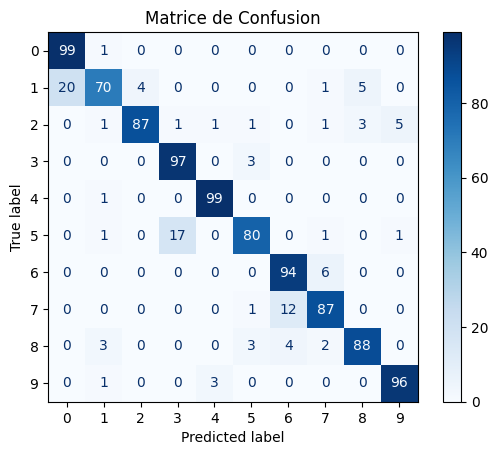

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d




DOMAIN_FOLDER =r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain4base\DOMAIN4_CSVcorrigé"

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except FileNotFoundError:
                continue
            except Exception:
                continue

print(f"Nombre total d'observations chargées : {len(df)}")


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)



def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation des données...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    groups = df_input.groupby(["gesture", "subject", "iter"])

    for (gesture, subject, iteration), group in groups:
        n = len(group)
        if n < 2: continue

        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)

        res_dict = {
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len
        }

        for col in ["x_std", "y_std", "z_std"]:
            res_dict[col] = interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame(res_dict))

    return pd.concat(resampled_data, ignore_index=True)

print("Resampling à 100 points...")
df100 = resample_gesture(df)



def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def gesture_to_sequence(df_sym):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_sym.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def assign_symbols(df_local):
        pts = df_local[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_copy = df_local.copy()
        df_copy["symbol"] = symbols
        return df_copy

    return gesture_to_sequence(assign_symbols(df_train)), gesture_to_sequence(assign_symbols(df_test))

def knn_edit_predict(seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]


def dict_creation_userout(df_in, subj_out):
    return df_in[df_in["subject"] != subj_out], df_in[df_in["subject"] == subj_out]

def testmodel(df_target, loop_range=10, k_knn=7, k_clusters=50):
    total_true, total_pred = [], []

    for i in range(1, loop_range + 1):
        print(f"Test sur sujet sorti : {i}")
        train_df, test_df = dict_creation_userout(df_target, i)

        if test_df.empty: continue

        train_seq, test_seq = cluster_and_convert(train_df, test_df, k_clusters)

        y_true, y_pred = [], []
        for gesture, sequences in test_seq.items():
            for seq in sequences:
                pred = knn_edit_predict(seq, train_seq, k=k_knn)
                y_true.append(gesture)
                y_pred.append(pred)

        total_true.extend(y_true)
        total_pred.extend(y_pred)
        print(f"Précision split : {accuracy_score(y_true, y_pred):.2%}")


    print(f"\n=== EXACTITUDE GLOBALE : {accuracy_score(total_true, total_pred):.2%} ===")
    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de Confusion")
    plt.show()


testmodel(df100)

# lcss knn 3 clsurr 20

--- Début du Chargement ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain4base\DOMAIN4_CSVcorrigé


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_6248\3286419123.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 139615
Standardisation en cours...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_6248\3286419123.py:74: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

--- TEST SUJET SORTI : 1 ---
Précision sujet 1 : 82.00%

--- TEST SUJET SORTI : 2 ---
Précision sujet 2 : 77.00%

--- TEST SUJET SORTI : 3 ---
Précision sujet 3 : 74.00%

--- TEST SUJET SORTI : 4 ---
Précision sujet 4 : 86.00%

--- TEST SUJET SORTI : 5 ---
Précision sujet 5 : 77.00%

--- TEST SUJET SORTI : 6 ---
Précision sujet 6 : 80.00%

--- TEST SUJET SORTI : 7 ---
Précision sujet 7 : 95.00%

--- TEST SUJET SORTI : 8 ---
Précision sujet 8 : 86.00%

--- TEST SUJET SORTI : 9 ---
Précision sujet 9 : 100.00%

--- TEST SUJET SORTI : 10 ---
Précision sujet 10 : 75.00%

=== EXACTITUDE GLOBALE KNN-LCSS : 83.20% ===


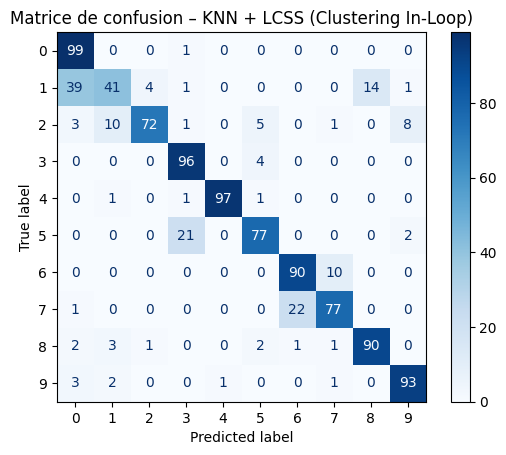

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d




DOMAIN_FOLDER =r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain4base\DOMAIN4_CSVcorrigé"

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des meta-données
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except FileNotFoundError:
                continue
            except Exception:
                continue


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")



def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:

        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)



def cluster_and_symbolize(train_df, test_df, k_clusters=20):

    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)

        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append("".join(group['symbol'].tolist()))
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)


def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):

    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = lcs_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]



def testmodel(df_input, loop_range=10, k_knn=3, k_clusters=20):
    total_true, total_pred = [], []

    for i in range(1, loop_range + 1):

        train_df = df_input[df_input["subject"] != i]
        test_df = df_input[df_input["subject"] == i]

        if test_df.empty:
            continue

        print(f"\n--- TEST SUJET SORTI : {i} ---")


        train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

        y_true, y_pred = [], []
        for gesture, sequences in test_dict.items():
            for seq in sequences:
                pred = knn_lcs_predict(seq, train_dict, k=k_knn)
                y_true.append(gesture)
                y_pred.append(pred)

        acc = accuracy_score(y_true, y_pred)
        print(f"Précision sujet {i} : {acc:.2%}")
        total_true.extend(y_true)
        total_pred.extend(y_pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE KNN-LCSS : {final_acc:.2%} ===")


    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de confusion – KNN + LCSS (Clustering In-Loop)")
    plt.show()


testmodel(df100)

#trans

--- 1. Début du Chargement du Domaine 4 ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain4base\DOMAIN4_CSVcorrigé
Nombre total d'observations chargées : 139615


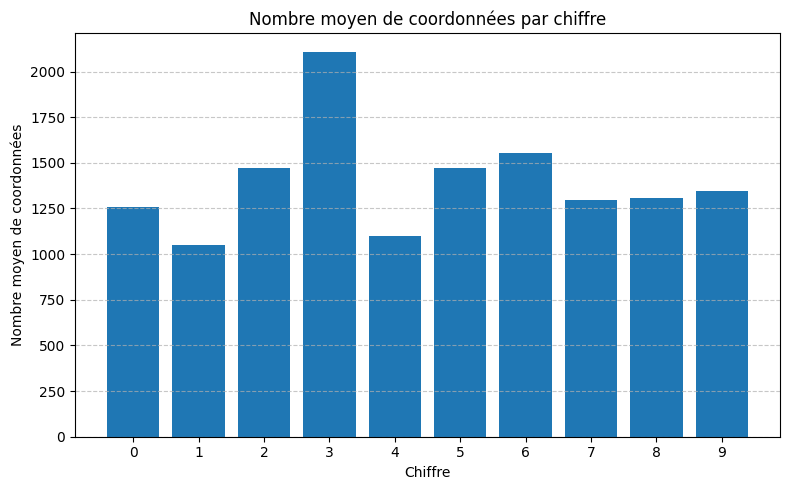

Chiffre 0 : 5617.80 s
Chiffre 1 : 4471.30 s
Chiffre 2 : 6968.80 s
Chiffre 3 : 9840.80 s
Chiffre 4 : 4995.50 s
Chiffre 5 : 6658.20 s
Chiffre 6 : 7136.30 s
Chiffre 7 : 5698.10 s
Chiffre 8 : 6041.50 s
Chiffre 9 : 6774.80 s


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_6284\1615355736.py:108: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



--- Test subject OUT : 1 ---

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 217ms/step - accuracy: 0.1011 - loss: 2.4170
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 220ms/step - accuracy: 0.4133 - loss: 1.5941
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 219ms/step - accuracy: 0.7656 - loss: 0.6322
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - accuracy: 0.8756 - loss: 0.3411
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 227ms/step - accuracy: 0.9189 - loss: 0.2694
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step - accuracy: 0.9600 - loss: 0.1469
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 227ms/step - accuracy: 0.9533 - loss: 0.1583
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - accuracy: 0.9767 - loss: 0.0853
Epoch 9/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - accuracy: 0.9822 - loss: 0.0821
Epoch 10/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - accuracy: 0.9767 - loss: 0.0627
Epoch 11/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - accuracy: 0.9789 - loss: 0.0766
Epoch 12/50
29/29 ━━

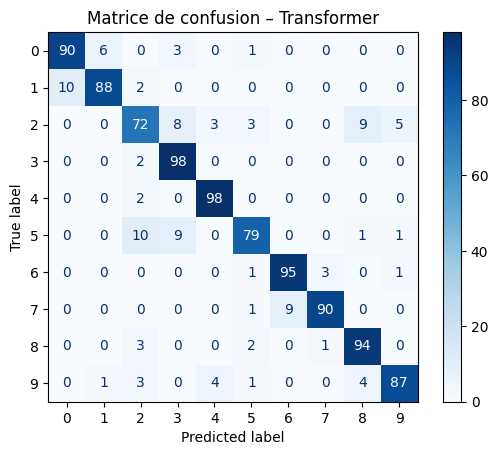

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf




DOMAIN_FOLDER =r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain4base\DOMAIN4_CSVcorrigé"
DOMAIN_ID = 4


df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2: continue


                data = file[0].str.strip('"').str.split(',', expand=True)

                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df_list.append(file_df)

            except FileNotFoundError:
                continue
            except Exception:
                continue


if not df_list:
    raise ValueError("Aucun fichier n'a pu être chargé. Vérifiez le chemin et le format des fichiers.")

df = pd.concat(df_list, ignore_index=True)


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")



grouped = df.groupby(['gesture', 'iter'])
sequence_lengths = grouped.size().reset_index(name='length')
mean_lengths = sequence_lengths.groupby('gesture')['length'].mean().reset_index()
mean_lengths.columns = ['Chiffre', 'Frames moyennes']

plt.figure(figsize=(8, 5))
plt.bar(mean_lengths["Chiffre"], mean_lengths["Frames moyennes"])
plt.title("Nombre moyen de coordonnées par chiffre")
plt.xlabel("Chiffre")
plt.ylabel("Nombre moyen de coordonnées")
plt.xticks(mean_lengths["Chiffre"])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
for gesture, mean_dur in mean_durations.items():
    print(f"Chiffre {gesture} : {mean_dur:.2f} s")



def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        if std == 0 or np.isnan(std):
            df_copy[f'{axis}_std'] = 0.0
        else:
            df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)




def resample_gesture(df_in, target_len=100):
    resampled_data = []

    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue

        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))

    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)




def create_user_independent_split(df_in, subj_out):
    train_df = df_in[df_in['subject'] != subj_out]
    test_df = df_in[df_in['subject'] == subj_out]

    def df_to_array(df_target):
        X, y = [], []
        for (gesture, subject, iteration), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(gesture)
        return np.array(X), np.array(y)

    X_train, y_train = df_to_array(train_df)
    X_test, y_test = df_to_array(test_df)
    return X_train, y_train, X_test, y_test




class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]




def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

    ffn = models.Sequential([
        layers.Dense(dff, activation="relu"),
        layers.Dense(d_model),
    ])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    out2 = layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)
    return out2

def create_transformer_model(input_shape, num_classes, seq_len=100):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2

    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(seq_len, d_model)(x)

    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model




def test_transformer_user_independent(df_data, loop_range=10, epochs=30, batch_size=32, verbose_fit=1):
    total_true, total_pred = [], []

    for subj_out in range(1, loop_range + 1):
        if df_data[df_data['subject'] == subj_out].empty: continue

        print(f"\n--- Test subject OUT : {subj_out} ---")
        X_train, y_train, X_test, y_test = create_user_independent_split(df_data, subj_out)

        n_classes = len(np.unique(df_data['gesture']))
        input_shape = (X_train.shape[1], X_train.shape[2])

        model = create_transformer_model(input_shape=input_shape, num_classes=n_classes)
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=verbose_fit)

        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred)
        print(f"Exactitude subject {subj_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(y_pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\nExactitude globale Transformer : {final_acc:.2%}")

    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de confusion – Transformer")
    plt.show()

test_transformer_user_independent(df100, loop_range=10, epochs=50, batch_size=32, verbose_fit=1)

# lstm batch size 32

--- 1. Début du Chargement du Domaine 4 ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain4base\DOMAIN4_CSVcorrigé
✅ Nombre total d'observations chargées : 139615

--- 2. Analyse Exploratoire ---


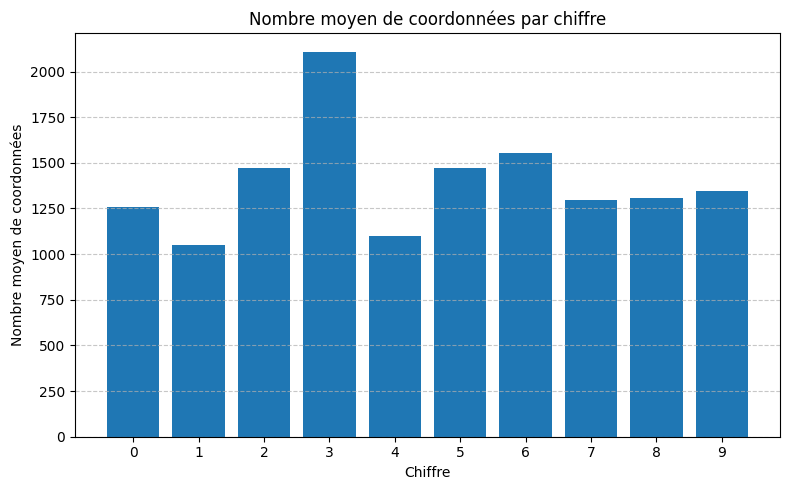

Chiffre 0 : 5617.80 s
Chiffre 1 : 4471.30 s
Chiffre 2 : 6968.80 s
Chiffre 3 : 9840.80 s
Chiffre 4 : 4995.50 s
Chiffre 5 : 6658.20 s
Chiffre 6 : 7136.30 s
Chiffre 7 : 5698.10 s
Chiffre 8 : 6041.50 s
Chiffre 9 : 6774.80 s

Standardisation...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_10152\347728140.py:105: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling à longueur 100...

--- Test subject OUT : 1 ---


\\student.fucam.ac.be\users$\isadiki\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Exactitude subject 1 : 93.00%

--- Test subject OUT : 2 ---


...

Exactitude subject 8 : 81.00%

--- Test subject OUT : 9 ---


\\student.fucam.ac.be\users$\isadiki\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Exactitude subject 9 : 100.00%

--- Test subject OUT : 10 ---


\\student.fucam.ac.be\users$\isadiki\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Exactitude subject 10 : 78.00%

Exactitude globale LSTM : 88.70%


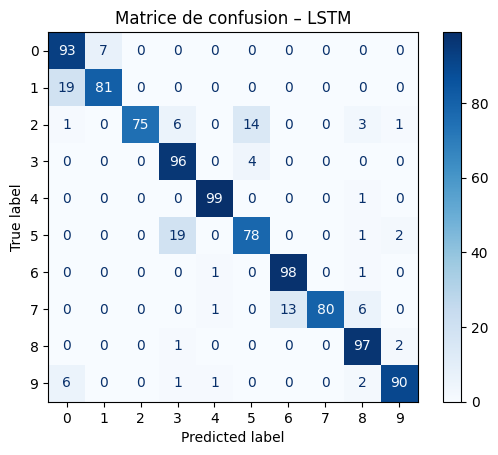

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers




DOMAIN_FOLDER = r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain4base\DOMAIN4_CSVcorrigé"
DOMAIN_ID = 4

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2: continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df_list.append(file_df)

            except (FileNotFoundError, Exception):
                continue


if not df_list:
    raise ValueError("❌ Aucun fichier n'a été chargé. Vérifiez le chemin : " + DOMAIN_FOLDER)

df = pd.concat(df_list, ignore_index=True)


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"✅ Nombre total d'observations chargées : {len(df)}")



print("\n--- 2. Analyse Exploratoire ---")
grouped = df.groupby(['gesture', 'iter'])
sequence_lengths = grouped.size().reset_index(name='length')
mean_lengths = sequence_lengths.groupby('gesture')['length'].mean().reset_index()
mean_lengths.columns = ['Chiffre', 'Frames moyennes']

plt.figure(figsize=(8, 5))
plt.bar(mean_lengths["Chiffre"], mean_lengths["Frames moyennes"])
plt.title("Nombre moyen de coordonnées par chiffre")
plt.xlabel("Chiffre")
plt.ylabel("Nombre moyen de coordonnées")
plt.xticks(mean_lengths["Chiffre"])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
for gesture, mean_dur in mean_durations.items():
    print(f"Chiffre {gesture} : {mean_dur:.2f} s")



def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        if std == 0 or np.isnan(std):
            df_copy[f'{axis}_std'] = 0.0
        else:
            df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std
    return df_copy

print("\nStandardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling à longueur 100...")
df100 = resample_gesture(df)



def create_user_independent_split(df_in, subj_out):
    train_df = df_in[df_in['subject'] != subj_out]
    test_df = df_in[df_in['subject'] == subj_out]

    def df_to_array(df_target):
        X, y = [], []
        for (gesture, subject, iteration), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(gesture)
        return np.array(X), np.array(y)

    X_train, y_train = df_to_array(train_df)
    X_test, y_test = df_to_array(test_df)
    return X_train, y_train, X_test, y_test



def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, dropout=0.2, input_shape=input_shape),
        layers.LSTM(256, dropout=0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model



def test_lstm_user_independent(df_data, loop_range=10, epochs=50, batch_size=32):
    total_true, total_pred = [], []
    subjects = sorted(df_data['subject'].unique())

    for subj_out in subjects:
        print(f"\n--- Test subject OUT : {subj_out} ---")
        X_train, y_train, X_test, y_test = create_user_independent_split(df_data, subj_out)


        all_labels = np.unique(df_data['gesture'])
        num_classes = int(max(all_labels) + 1)

        model = create_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]), num_classes=num_classes)


        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)


        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred)
        print(f"Exactitude subject {subj_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(y_pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\nExactitude globale LSTM : {final_acc:.2%}")


    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de confusion – LSTM")
    plt.show()


test_lstm_user_independent(df100)

#dtw

# dtw total

--- Début du Chargement ---
✅ Données chargées : 139615 lignes.


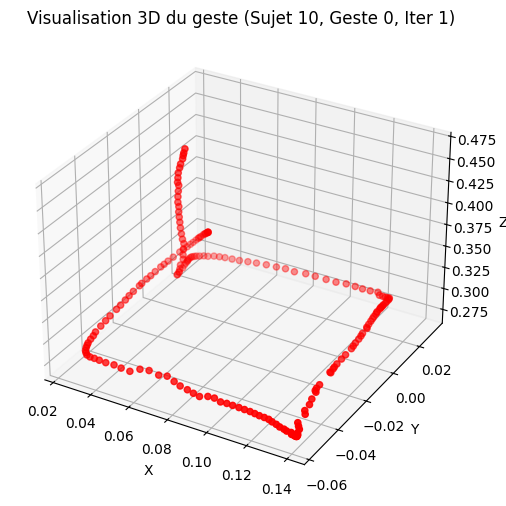


--- Durée moyenne des gestes (s) ---
gesture
0    5617.8
1    4471.3
2    6968.8
3    9840.8
4    4995.5
5    6658.2
6    7136.3
7    5698.1
8    6041.5
9    6774.8
Name: duration, dtype: float64


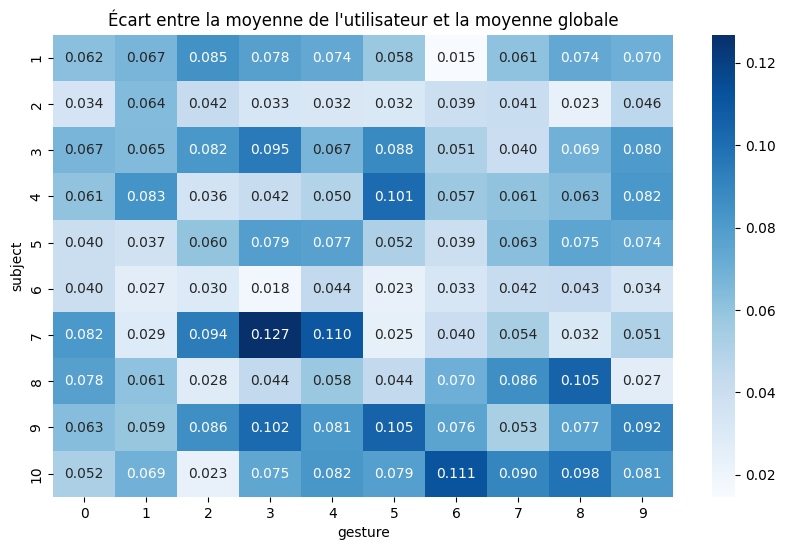

Standardisation...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_4996\1890533262.py:112: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling...

--- Test Split OUT : 1 ---
Précision split 1 : 88.00%

--- Test Split OUT : 2 ---
Précision split 2 : 90.00%

--- Test Split OUT : 3 ---
Précision split 3 : 87.00%

--- Test Split OUT : 4 ---
Précision split 4 : 95.00%

--- Test Split OUT : 5 ---
Précision split 5 : 85.00%

--- Test Split OUT : 6 ---
Précision split 6 : 88.00%

--- Test Split OUT : 7 ---
Précision split 7 : 98.00%

--- Test Split OUT : 8 ---
Précision split 8 : 86.00%

--- Test Split OUT : 9 ---
Précision split 9 : 100.00%

--- Test Split OUT : 10 ---
Précision split 10 : 74.00%

✅ Précision GLOBALE : 89.10%


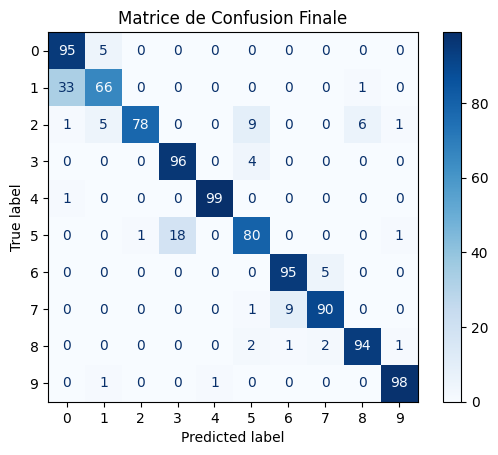

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp1d
import seaborn as sns



DOMAIN_FOLDER =  r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain4base\DOMAIN4_CSVcorrigé"

df_list = []

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = int(number)
                file_df['subject'] = int(subject)
                file_df['iter'] = int(iteration)

                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("❌ Aucun fichier chargé. Vérifiez le chemin : " + DOMAIN_FOLDER)

df = pd.concat(df_list, ignore_index=True)
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"✅ Données chargées : {len(df)} lignes.")



subdf = df.loc[(df['gesture'] == 0) & (df['subject'] == 10) & (df['iter'] == 1)]

if not subdf.empty:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    # ax.plot(...) a été supprimé ici pour enlever le tracé bleu
    ax.scatter(subdf['x'], subdf['y'], subdf['z'], c='red', s=20)
    ax.set_title("Visualisation 3D du geste (Sujet 10, Geste 0, Iter 1)")
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.show()




durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
print("\n--- Durée moyenne des gestes (s) ---")
print(mean_durations)


mean_coords_user = df.groupby(['subject', 'gesture'])[['x', 'y', 'z']].mean().reset_index()
mean_coords_global = df.groupby('gesture')[['x', 'y', 'z']].mean().reset_index().rename(
    columns={'x':'x_global', 'y':'y_global', 'z':'z_global'})

merged = pd.merge(mean_coords_user, mean_coords_global, on='gesture')
merged['dist_to_global'] = np.sqrt((merged['x']-merged['x_global'])**2 +
                                   (merged['y']-merged['y_global'])**2 +
                                   (merged['z']-merged['z_global'])**2)

pivot = merged.pivot(index='subject', columns='gesture', values='dist_to_global')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap='Blues')
plt.title("Écart entre la moyenne de l'utilisateur et la moyenne globale")
plt.show()



def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)



def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]



def dict_creation_userout(df, subj_out):
    test_df = df[df["subject"] == subj_out]
    train_df = df[df["subject"] != subj_out]

    dict_train = defaultdict(list)
    dict_test = defaultdict(list)

    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())
    for (g, s, it), group in test_df.groupby(["gesture", "subject", "iter"]):
        dict_test[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())
    return dict_train, dict_test

def testmodel(DictCreationFunc, df, loop_range=10, k=3):
    total_true, total_pred = [], []
    for i in range(1, loop_range + 1):
        print(f"\n--- Test Split OUT : {i} ---")
        coord_train, coord_test = DictCreationFunc(df, i)
        y_true, y_pred = [], []
        for gesture, sequences in coord_test.items():
            for seq in sequences:
                pred = knn_dtw_predict(seq, coord_train, k=k)
                y_true.append(gesture)
                y_pred.append(pred)

        acc = accuracy_score(y_true, y_pred)
        total_true.extend(y_true); total_pred.extend(y_pred)
        print(f"Précision split {i} : {acc:.2%}")

    print(f"\n✅ Précision GLOBALE : {accuracy_score(total_true, total_pred):.2%}")
    cm = confusion_matrix(total_true, total_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title("Matrice de Confusion Finale")
    plt.show()

# LANCEMENT FINAL
testmodel(dict_creation_userout, df100, loop_range=10, k=3)

# partie 2

## lcss cluster 5 knn 3 traine 4 tes 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Logique du Code 1)
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture avec saut de lignes pour nettoyer le header spécifique
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except (FileNotFoundError, Exception):
                continue

# Conversion finale des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE CLUSTERING ET ALGORITHMES (KNN + LCSS)
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=5):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            # On stocke le sujet pour le reporting final
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. TEST FINAL (Logique du Code 2 : Sujet 3 exclu, Split 4/5)
# ===========================================================

def run_experiment_fixed(df_input, k_knn=3, k_clusters=5):
    all_subjects = sorted(df_input['subject'].unique().tolist())

    # Exclusion manuelle du sujet 3
    subject_removed = 3
    print(f"\n>>> CONFIGURATION : Le sujet {subject_removed} est exclu de l'expérience.")

    remaining = [s for s in all_subjects if s != subject_removed]

    # Split séquentiel : 4 premiers pour Train, 5 restants pour Test
    train_subjects = remaining[:4]
    test_subjects = remaining[4:]

    print(f"Sujets d'entraînement (Train) : {train_subjects}")
    print(f"Sujets de prédiction (Test)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    # Transformation en séquences de symboles
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS (cela peut prendre un moment)...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)

            total_true.append(gesture)
            total_pred.append(pred)

            # Stockage par sujet pour détail
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    # Affichage des résultats par sujet
    print("\n--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    # Moyenne globale
    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE (Sujets {test_subjects}) : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_experiment_fixed(df100)
else:
    print("Erreur : Aucune donnée n'a été chargée.")

--- Début du Chargement ---
Dossier source : /Users/iliassadiki/Downloads/DOMAIN4_CSV


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/2867930713.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 126156
Standardisation en cours...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/2867930713.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

>>> CONFIGURATION : Le sujet 3 est exclu de l'expérience.
Sujets d'entraînement (Train) : [1, 2, 4, 5]
Sujets de prédiction (Test)  : [6, 7, 8, 9, 10]

Calcul des prédictions LCSS (cela peut prendre un moment)...

--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---
Précision Sujet 6 : 58.89%
Précision Sujet 7 : 68.89%
Précision Sujet 8 : 81.11%
Précision Sujet 9 : 81.11%
Précision Sujet 10 : 55.56%

=== EXACTITUDE GLOBALE (Sujets [6, 7, 8, 9, 10]) : 69.11% ===


## lcss cluster 5 knn 3 traine 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=5):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Split 5 Train Fin / 4 Test Début)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=5):
    # Définition manuelle des listes selon ta demande
    train_subjects = [6, 7, 8, 9, 10]
    test_subjects = [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE SUR {len(test_subjects)} SUJETS : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/997921587.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/997921587.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions LCSS...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 74.44%
Précision Sujet 2 : 75.56%
Précision Sujet 4 : 68.89%
Précision Sujet 5 : 68.89%

=== EXACTITUDE GLOBALE SUR 4 SUJETS : 71.94% ===


# lcss cluster 5 knn 3 test sur sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=5):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE : TRAIN TOUT SAUF 3 | TEST SUR 3
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=5):
    # Train sur tout sauf le sujet 3
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    # Test uniquement sur le sujet 3
    test_subjects = [3]

    print(f"\n>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<")
    print(f"Sujets d'entraînement (9) : {train_subjects}")
    print(f"Sujet de test (1)         : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le sujet 3 ou les autres.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []

    print("Calcul des prédictions LCSS pour le sujet 3...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== PRÉCISION FINALE SUR LE SUJET 3 : {final_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/2953811871.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/2953811871.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<
Sujets d'entraînement (9) : [1, 2, 4, 5, 6, 7, 8, 9, 10]
Sujet de test (1)         : [3]

Calcul des prédictions LCSS pour le sujet 3...

=== PRÉCISION FINALE SUR LE SUJET 3 : 70.00% ===


# lcss cluster 20 knn3 traine 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Logique du Code 1)
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture avec saut de lignes pour nettoyer le header spécifique
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except (FileNotFoundError, Exception):
                continue

# Conversion finale des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE CLUSTERING ET ALGORITHMES (KNN + LCSS)
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            # On stocke le sujet pour le reporting final
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. TEST FINAL (Logique du Code 2 : Sujet 3 exclu, Split 4/5)
# ===========================================================

def run_experiment_fixed(df_input, k_knn=3, k_clusters=20):
    all_subjects = sorted(df_input['subject'].unique().tolist())

    # Exclusion manuelle du sujet 3
    subject_removed = 3
    print(f"\n>>> CONFIGURATION : Le sujet {subject_removed} est exclu de l'expérience.")

    remaining = [s for s in all_subjects if s != subject_removed]

    # Split séquentiel : 4 premiers pour Train, 5 restants pour Test
    train_subjects = remaining[:4]
    test_subjects = remaining[4:]

    print(f"Sujets d'entraînement (Train) : {train_subjects}")
    print(f"Sujets de prédiction (Test)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    # Transformation en séquences de symboles
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS (cela peut prendre un moment)...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)

            total_true.append(gesture)
            total_pred.append(pred)

            # Stockage par sujet pour détail
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    # Affichage des résultats par sujet
    print("\n--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    # Moyenne globale
    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE (Sujets {test_subjects}) : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_experiment_fixed(df100)
else:
    print("Erreur : Aucune donnée n'a été chargée.")

--- Début du Chargement ---
Dossier source : /Users/iliassadiki/Downloads/DOMAIN4_CSV


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/3833248958.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 126156
Standardisation en cours...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/3833248958.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

>>> CONFIGURATION : Le sujet 3 est exclu de l'expérience.
Sujets d'entraînement (Train) : [1, 2, 4, 5]
Sujets de prédiction (Test)  : [6, 7, 8, 9, 10]

Calcul des prédictions LCSS (cela peut prendre un moment)...

--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---
Précision Sujet 6 : 77.78%
Précision Sujet 7 : 93.33%
Précision Sujet 8 : 82.22%
Précision Sujet 9 : 90.00%
Précision Sujet 10 : 70.00%

=== EXACTITUDE GLOBALE (Sujets [6, 7, 8, 9, 10]) : 82.67% ===


# lcss cluster 20 knn 3 traine 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Split 5 Train Fin / 4 Test Début)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=20):
    # Définition manuelle des listes selon ta demande
    train_subjects = [6, 7, 8, 9, 10]
    test_subjects = [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE SUR {len(test_subjects)} SUJETS : {global_acc:.2%} ===")


# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/2868535272.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/2868535272.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions LCSS...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 78.89%
Précision Sujet 2 : 81.11%
Précision Sujet 4 : 76.67%
Précision Sujet 5 : 80.00%

=== EXACTITUDE GLOBALE SUR 4 SUJETS : 79.17% ===


# lcs cluster 20 knn3 test sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE : TRAIN TOUT SAUF 3 | TEST SUR 3
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=20):
    # Train sur tout sauf le sujet 3
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    # Test uniquement sur le sujet 3
    test_subjects = [3]

    print(f"\n>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<")
    print(f"Sujets d'entraînement (9) : {train_subjects}")
    print(f"Sujet de test (1)         : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le sujet 3 ou les autres.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []

    print("Calcul des prédictions LCSS pour le sujet 3...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== PRÉCISION FINALE SUR LE SUJET 3 : {final_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/3869766258.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/3869766258.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<
Sujets d'entraînement (9) : [1, 2, 4, 5, 6, 7, 8, 9, 10]
Sujet de test (1)         : [3]

Calcul des prédictions LCSS pour le sujet 3...

=== PRÉCISION FINALE SUR LE SUJET 3 : 74.44% ===


# lcss clusyter 50 knn 3 traine 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Logique du Code 1)
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture avec saut de lignes pour nettoyer le header spécifique
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except (FileNotFoundError, Exception):
                continue

# Conversion finale des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE CLUSTERING ET ALGORITHMES (KNN + LCSS)
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            # On stocke le sujet pour le reporting final
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. TEST FINAL (Logique du Code 2 : Sujet 3 exclu, Split 4/5)
# ===========================================================

def run_experiment_fixed(df_input, k_knn=3, k_clusters=50):
    all_subjects = sorted(df_input['subject'].unique().tolist())

    # Exclusion manuelle du sujet 3
    subject_removed = 3
    print(f"\n>>> CONFIGURATION : Le sujet {subject_removed} est exclu de l'expérience.")

    remaining = [s for s in all_subjects if s != subject_removed]

    # Split séquentiel : 4 premiers pour Train, 5 restants pour Test
    train_subjects = remaining[:4]
    test_subjects = remaining[4:]

    print(f"Sujets d'entraînement (Train) : {train_subjects}")
    print(f"Sujets de prédiction (Test)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    # Transformation en séquences de symboles
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS (cela peut prendre un moment)...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)

            total_true.append(gesture)
            total_pred.append(pred)

            # Stockage par sujet pour détail
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    # Affichage des résultats par sujet
    print("\n--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    # Moyenne globale
    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE (Sujets {test_subjects}) : {global_acc:.2%} ===")


# LANCEMENT
if not df100.empty:
    run_experiment_fixed(df100)
else:
    print("Erreur : Aucune donnée n'a été chargée.")

--- Début du Chargement ---
Dossier source : /Users/iliassadiki/Downloads/DOMAIN4_CSV


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/3605467395.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 126156
Standardisation en cours...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/3605467395.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

>>> CONFIGURATION : Le sujet 3 est exclu de l'expérience.
Sujets d'entraînement (Train) : [1, 2, 4, 5]
Sujets de prédiction (Test)  : [6, 7, 8, 9, 10]

Calcul des prédictions LCSS (cela peut prendre un moment)...

--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---
Précision Sujet 6 : 68.89%
Précision Sujet 7 : 88.89%
Précision Sujet 8 : 80.00%
Précision Sujet 9 : 91.11%
Précision Sujet 10 : 71.11%

=== EXACTITUDE GLOBALE (Sujets [6, 7, 8, 9, 10]) : 80.00% ===


# lcss cluster 50 knn 3 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Split 5 Train Fin / 4 Test Début)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=50):
    # Définition manuelle des listes selon ta demande
    train_subjects = [6, 7, 8, 9, 10]
    test_subjects = [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE SUR {len(test_subjects)} SUJETS : {global_acc:.2%} ===")


# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/4056542318.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/4056542318.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions LCSS...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 81.11%
Précision Sujet 2 : 77.78%
Précision Sujet 4 : 72.22%
Précision Sujet 5 : 73.33%

=== EXACTITUDE GLOBALE SUR 4 SUJETS : 76.11% ===


# lcs cluster 50 knnn 3 test sur sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE : TRAIN TOUT SAUF 3 | TEST SUR 3
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=50):
    # Train sur tout sauf le sujet 3
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    # Test uniquement sur le sujet 3
    test_subjects = [3]

    print(f"\n>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<")
    print(f"Sujets d'entraînement (9) : {train_subjects}")
    print(f"Sujet de test (1)         : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le sujet 3 ou les autres.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []

    print("Calcul des prédictions LCSS pour le sujet 3...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== PRÉCISION FINALE SUR LE SUJET 3 : {final_acc:.2%} ===")


# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/682863056.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/682863056.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<
Sujets d'entraînement (9) : [1, 2, 4, 5, 6, 7, 8, 9, 10]
Sujet de test (1)         : [3]

Calcul des prédictions LCSS pour le sujet 3...

=== PRÉCISION FINALE SUR LE SUJET 3 : 76.67% ===


# lcs cluster 20 knn 5 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Logique du Code 1)
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture avec saut de lignes pour nettoyer le header spécifique
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except (FileNotFoundError, Exception):
                continue

# Conversion finale des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE CLUSTERING ET ALGORITHMES (KNN + LCSS)
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            # On stocke le sujet pour le reporting final
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=5):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. TEST FINAL (Logique du Code 2 : Sujet 3 exclu, Split 4/5)
# ===========================================================

def run_experiment_fixed(df_input, k_knn=5, k_clusters=20):
    all_subjects = sorted(df_input['subject'].unique().tolist())

    # Exclusion manuelle du sujet 3
    subject_removed = 3
    print(f"\n>>> CONFIGURATION : Le sujet {subject_removed} est exclu de l'expérience.")

    remaining = [s for s in all_subjects if s != subject_removed]

    # Split séquentiel : 4 premiers pour Train, 5 restants pour Test
    train_subjects = remaining[:4]
    test_subjects = remaining[4:]

    print(f"Sujets d'entraînement (Train) : {train_subjects}")
    print(f"Sujets de prédiction (Test)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    # Transformation en séquences de symboles
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS (cela peut prendre un moment)...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)

            total_true.append(gesture)
            total_pred.append(pred)

            # Stockage par sujet pour détail
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    # Affichage des résultats par sujet
    print("\n--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    # Moyenne globale
    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE (Sujets {test_subjects}) : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_experiment_fixed(df100)
else:
    print("Erreur : Aucune donnée n'a été chargée.")

--- Début du Chargement ---
Dossier source : /Users/iliassadiki/Downloads/DOMAIN4_CSV


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/1820515476.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 126156
Standardisation en cours...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/1820515476.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

>>> CONFIGURATION : Le sujet 3 est exclu de l'expérience.
Sujets d'entraînement (Train) : [1, 2, 4, 5]
Sujets de prédiction (Test)  : [6, 7, 8, 9, 10]

Calcul des prédictions LCSS (cela peut prendre un moment)...

--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---
Précision Sujet 6 : 78.89%
Précision Sujet 7 : 92.22%
Précision Sujet 8 : 81.11%
Précision Sujet 9 : 88.89%
Précision Sujet 10 : 70.00%

=== EXACTITUDE GLOBALE (Sujets [6, 7, 8, 9, 10]) : 82.22% ===


# lcs cluster 20 knnn 5 traine 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=5):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Split 5 Train Fin / 4 Test Début)
# ===========================================================

def run_custom_experiment(df_input, k_knn=5, k_clusters=20):
    # Définition manuelle des listes selon ta demande
    train_subjects = [6, 7, 8, 9, 10]
    test_subjects = [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE SUR {len(test_subjects)} SUJETS : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/1473148943.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/1473148943.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions LCSS...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 76.67%
Précision Sujet 2 : 81.11%
Précision Sujet 4 : 76.67%
Précision Sujet 5 : 76.67%

=== EXACTITUDE GLOBALE SUR 4 SUJETS : 77.78% ===


# lcs cluster 20 knn 5 test sur sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=5):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE : TRAIN TOUT SAUF 3 | TEST SUR 3
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=5, k_clusters=20):
    # Train sur tout sauf le sujet 3
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    # Test uniquement sur le sujet 3
    test_subjects = [3]

    print(f"\n>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<")
    print(f"Sujets d'entraînement (9) : {train_subjects}")
    print(f"Sujet de test (1)         : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le sujet 3 ou les autres.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []

    print("Calcul des prédictions LCSS pour le sujet 3...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== PRÉCISION FINALE SUR LE SUJET 3 : {final_acc:.2%} ===")


# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/488214884.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/488214884.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<
Sujets d'entraînement (9) : [1, 2, 4, 5, 6, 7, 8, 9, 10]
Sujet de test (1)         : [3]

Calcul des prédictions LCSS pour le sujet 3...

=== PRÉCISION FINALE SUR LE SUJET 3 : 74.44% ===


# lcs cluster 20 knn 7 traine 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Logique du Code 1)
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                # Lecture avec saut de lignes pour nettoyer le header spécifique
                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except (FileNotFoundError, Exception):
                continue

# Conversion finale des types
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE CLUSTERING ET ALGORITHMES (KNN + LCSS)
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            # On stocke le sujet pour le reporting final
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=7):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. TEST FINAL (Logique du Code 2 : Sujet 3 exclu, Split 4/5)
# ===========================================================

def run_experiment_fixed(df_input, k_knn=7, k_clusters=20):
    all_subjects = sorted(df_input['subject'].unique().tolist())

    # Exclusion manuelle du sujet 3
    subject_removed = 3
    print(f"\n>>> CONFIGURATION : Le sujet {subject_removed} est exclu de l'expérience.")

    remaining = [s for s in all_subjects if s != subject_removed]

    # Split séquentiel : 4 premiers pour Train, 5 restants pour Test
    train_subjects = remaining[:4]
    test_subjects = remaining[4:]

    print(f"Sujets d'entraînement (Train) : {train_subjects}")
    print(f"Sujets de prédiction (Test)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    # Transformation en séquences de symboles
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS (cela peut prendre un moment)...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)

            total_true.append(gesture)
            total_pred.append(pred)

            # Stockage par sujet pour détail
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    # Affichage des résultats par sujet
    print("\n--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    # Moyenne globale
    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE (Sujets {test_subjects}) : {global_acc:.2%} ===")


# LANCEMENT
if not df100.empty:
    run_experiment_fixed(df100)
else:
    print("Erreur : Aucune donnée n'a été chargée.")

--- Début du Chargement ---
Dossier source : /Users/iliassadiki/Downloads/DOMAIN4_CSV


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/846898797.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 126156
Standardisation en cours...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/846898797.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

>>> CONFIGURATION : Le sujet 3 est exclu de l'expérience.
Sujets d'entraînement (Train) : [1, 2, 4, 5]
Sujets de prédiction (Test)  : [6, 7, 8, 9, 10]

Calcul des prédictions LCSS (cela peut prendre un moment)...

--- RÉSULTATS DÉTAILLÉS PAR SUJET TEST ---
Précision Sujet 6 : 80.00%
Précision Sujet 7 : 92.22%
Précision Sujet 8 : 76.67%
Précision Sujet 9 : 91.11%
Précision Sujet 10 : 70.00%

=== EXACTITUDE GLOBALE (Sujets [6, 7, 8, 9, 10]) : 82.00% ===


# lcs cluster 20 knn 7 traine 5 tesgt 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=7):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Split 5 Train Fin / 4 Test Début)
# ===========================================================

def run_custom_experiment(df_input, k_knn=7, k_clusters=20):
    # Définition manuelle des listes selon ta demande
    train_subjects = [6, 7, 8, 9, 10]
    test_subjects = [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions LCSS...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE SUR {len(test_subjects)} SUJETS : {global_acc:.2%} ===")


# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/1169725343.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/1169725343.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION DEMANDÉE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions LCSS...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 77.78%
Précision Sujet 2 : 76.67%
Précision Sujet 4 : 75.56%
Précision Sujet 5 : 76.67%

=== EXACTITUDE GLOBALE SUR 4 SUJETS : 76.67% ===


# lcs cluster 20 knn 7 test final sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT
# ===========================================================

DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE LCSS / KNN
# ===========================================================

def cluster_and_symbolize(train_df, test_df, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols
        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)

def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):
    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=7):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = lcs_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE : TRAIN TOUT SAUF 3 | TEST SUR 3
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=7, k_clusters=20):
    # Train sur tout sauf le sujet 3
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    # Test uniquement sur le sujet 3
    test_subjects = [3]

    print(f"\n>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<")
    print(f"Sujets d'entraînement (9) : {train_subjects}")
    print(f"Sujet de test (1)         : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le sujet 3 ou les autres.")
        return

    # Clustering et transformation
    train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

    total_true, total_pred = [], []

    print("Calcul des prédictions LCSS pour le sujet 3...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_lcs_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== PRÉCISION FINALE SUR LE SUJET 3 : {final_acc:.2%} ===")


# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/2321203228.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_14530/2321203228.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION : TEST SUR SUJET 3 UNIQUEMENT <<<
Sujets d'entraînement (9) : [1, 2, 4, 5, 6, 7, 8, 9, 10]
Sujet de test (1)         : [3]

Calcul des prédictions LCSS pour le sujet 3...

=== PRÉCISION FINALE SUR LE SUJET 3 : 75.56% ===


# edit cluster 5 knn 3 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=5):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=5):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =    [1, 2, 4, 5]
    test_subjects = [6, 7, 8, 9, 10]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1951657838.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1951657838.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [1, 2, 4, 5]
Sujets de prédiction (4)  : [6, 7, 8, 9, 10]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 6 : 57.78%
Précision Sujet 7 : 73.33%
Précision Sujet 8 : 83.33%
Précision Sujet 9 : 93.33%
Précision Sujet 10 : 53.33%

=== EXACTITUDE GLOBALE : 72.22% ===


# edit cluster 5 knn 3 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=5):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=5):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =  [6, 7, 8, 9, 10]
    test_subjects =  [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/959210416.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/959210416.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 75.56%
Précision Sujet 2 : 76.67%
Précision Sujet 4 : 73.33%
Précision Sujet 5 : 68.89%

=== EXACTITUDE GLOBALE : 73.61% ===


# edit cluster 5 knn 3 test sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
#               CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN3
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes (skiprows=5) pour ignorer les headers inutiles de DOMAIN3
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : on sépare les colonnes par la virgule et on retire les guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)

                # On ne garde que les 4 premières colonnes (x, y, z, t)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion en nombres et suppression des lignes vides (NaN)
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration

                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
#                FONCTIONS DE TRAITEMENT (Inchangées)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=5):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)

    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
#           TEST FINAL : 9 TRAIN / 1 TEST (Sujet 3)
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=5):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le test.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1445471924.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1445471924.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 71.11% ===


# edit cluster 20 knn 3 test 5 train 4 )

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=20):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =    [1, 2, 4, 5]
    test_subjects = [6, 7, 8, 9, 10]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/3373129982.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/3373129982.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [1, 2, 4, 5]
Sujets de prédiction (4)  : [6, 7, 8, 9, 10]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 6 : 71.11%
Précision Sujet 7 : 96.67%
Précision Sujet 8 : 81.11%
Précision Sujet 9 : 97.78%
Précision Sujet 10 : 72.22%

=== EXACTITUDE GLOBALE : 83.78% ===


# edit c luster 20 knn 3 train 5 tezst 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=20):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=20):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =  [6, 7, 8, 9, 10]
    test_subjects =  [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/229263192.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/229263192.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 84.44%
Précision Sujet 2 : 85.56%
Précision Sujet 4 : 86.67%
Précision Sujet 5 : 80.00%

=== EXACTITUDE GLOBALE : 84.17% ===


# edit cluster 20 knn 3 test sur sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
#               CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN3
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes (skiprows=5) pour ignorer les headers inutiles de DOMAIN3
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : on sépare les colonnes par la virgule et on retire les guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)

                # On ne garde que les 4 premières colonnes (x, y, z, t)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion en nombres et suppression des lignes vides (NaN)
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration

                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
#                FONCTIONS DE TRAITEMENT (Inchangées)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=20):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)

    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
#           TEST FINAL : 9 TRAIN / 1 TEST (Sujet 3)
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=20):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le test.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/575744726.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/575744726.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 78.89% ===


# edit cluster 50 knn3 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=50):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =    [1, 2, 4, 5]
    test_subjects = [6, 7, 8, 9, 10]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/3630555954.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/3630555954.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [1, 2, 4, 5]
Sujets de prédiction (4)  : [6, 7, 8, 9, 10]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 6 : 73.33%
Précision Sujet 7 : 91.11%
Précision Sujet 8 : 88.89%
Précision Sujet 9 : 96.67%
Précision Sujet 10 : 73.33%

=== EXACTITUDE GLOBALE : 84.67% ===


# edit cluster 50 knn 3 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=3, k_clusters=50):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =  [6, 7, 8, 9, 10]
    test_subjects =  [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1689217240.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1689217240.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 88.89%
Précision Sujet 2 : 83.33%
Précision Sujet 4 : 86.67%
Précision Sujet 5 : 78.89%

=== EXACTITUDE GLOBALE : 84.44% ===


# edit dist cluster 50 knn 3 test sur le sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
#               CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN3
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes (skiprows=5) pour ignorer les headers inutiles de DOMAIN3
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : on sépare les colonnes par la virgule et on retire les guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)

                # On ne garde que les 4 premières colonnes (x, y, z, t)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion en nombres et suppression des lignes vides (NaN)
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration

                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
#                FONCTIONS DE TRAITEMENT (Inchangées)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=50):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)

    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
#           TEST FINAL : 9 TRAIN / 1 TEST (Sujet 3)
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=3, k_clusters=50):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le test.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1672333672.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1672333672.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 81.11% ===


# edit cluster 50 knn 5 trzin 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=5):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=5, k_clusters=50):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =    [1, 2, 4, 5]
    test_subjects = [6, 7, 8, 9, 10]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/4105012169.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/4105012169.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [1, 2, 4, 5]
Sujets de prédiction (4)  : [6, 7, 8, 9, 10]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 6 : 71.11%
Précision Sujet 7 : 94.44%
Précision Sujet 8 : 83.33%
Précision Sujet 9 : 96.67%
Précision Sujet 10 : 70.00%

=== EXACTITUDE GLOBALE : 83.11% ===


# eedit cluster 50 knn 3 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=5):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=5, k_clusters=50):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =  [6, 7, 8, 9, 10]
    test_subjects =  [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1097578583.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1097578583.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 90.00%
Précision Sujet 2 : 82.22%
Précision Sujet 4 : 87.78%
Précision Sujet 5 : 77.78%

=== EXACTITUDE GLOBALE : 84.44% ===


# edit cluster 50 knnn 5 sueht 3 test

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
#               CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN3
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes (skiprows=5) pour ignorer les headers inutiles de DOMAIN3
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : on sépare les colonnes par la virgule et on retire les guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)

                # On ne garde que les 4 premières colonnes (x, y, z, t)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion en nombres et suppression des lignes vides (NaN)
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration

                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
#                FONCTIONS DE TRAITEMENT (Inchangées)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=50):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)

    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=5):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
#           TEST FINAL : 9 TRAIN / 1 TEST (Sujet 3)
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=5, k_clusters=50):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le test.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1589753864.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/1589753864.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 82.22% ===


# edit cluster 50 knn 7 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=7):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=7, k_clusters=50):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =    [1, 2, 4, 5]
    test_subjects = [6, 7, 8, 9, 10]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/2590775762.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/2590775762.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [1, 2, 4, 5]
Sujets de prédiction (4)  : [6, 7, 8, 9, 10]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 6 : 76.67%
Précision Sujet 7 : 95.56%
Précision Sujet 8 : 78.89%
Précision Sujet 9 : 95.56%
Précision Sujet 10 : 72.22%

=== EXACTITUDE GLOBALE : 83.78% ===


# edit cluster 50 knn 7 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
# 1. CONFIGURATION ET CHARGEMENT (Chemin Absolu DOMAIN2)
# ===========================================================

# Utilisation du chemin absolu comme dans ton premier code
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture brute pour gérer le formatage spécifique de DOMAIN2
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                # Nettoyage des données (split des virgules et retrait des guillemets)
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ===========================================================
# 2. PRÉ-TRAITEMENT (Standardisation & Resampling)
# ===========================================================

def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
# 3. LOGIQUE EDIT DISTANCE / KNN
# ===========================================================

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append({'subj': subj, 'seq': "".join(group['symbol'].tolist())})
        return seq_dict

    return to_seq_dict(df_train), to_seq_dict(df_test)

def knn_edit_predict(seq, train_dict, k=7):
    distances = []
    for gesture, data_list in train_dict.items():
        for item in data_list:
            d = edit_distance(seq, item['seq'])
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
# 4. EXPÉRIENCE PERSONNALISÉE (Edit Distance)
# ===========================================================

def run_custom_experiment(df_input, k_knn=7, k_clusters=50):
    # Sujets demandés : Train [6-10], Test [1, 2, 4, 5], Exclu [3]
    train_subjects =  [6, 7, 8, 9, 10]
    test_subjects =  [1, 2, 4, 5]

    print(f"\n>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<")
    print(f"Sujets d'entraînement (5) : {train_subjects}")
    print(f"Sujets de prédiction (4)  : {test_subjects}\n")

    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Un des sets est vide. Vérifie le chargement des données.")
        return

    # Clustering et transformation en séquences symboliques
    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)

    total_true, total_pred = [], []
    subject_scores = defaultdict(lambda: {"true": [], "pred": []})

    print("Calcul des prédictions Edit Distance...")
    for gesture, data_list in test_dict.items():
        for item in data_list:
            pred = knn_edit_predict(item['seq'], train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)
            subject_scores[item['subj']]["true"].append(gesture)
            subject_scores[item['subj']]["pred"].append(pred)

    print("\n--- RÉSULTATS PAR SUJET DE TEST ---")
    for s in test_subjects:
        if s in subject_scores:
            acc = accuracy_score(subject_scores[s]["true"], subject_scores[s]["pred"])
            print(f"Précision Sujet {s} : {acc:.2%}")

    global_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE : {global_acc:.2%} ===")



# LANCEMENT
if not df100.empty:
    run_custom_experiment(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/2598453105.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/2598453105.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

>>> CONFIGURATION EDIT DISTANCE (Sujet 3 exclu) <<<
Sujets d'entraînement (5) : [6, 7, 8, 9, 10]
Sujets de prédiction (4)  : [1, 2, 4, 5]

Calcul des prédictions Edit Distance...

--- RÉSULTATS PAR SUJET DE TEST ---
Précision Sujet 1 : 88.89%
Précision Sujet 2 : 83.33%
Précision Sujet 4 : 86.67%
Précision Sujet 5 : 75.56%

=== EXACTITUDE GLOBALE : 83.61% ===


# edit cluster 50 knn 7 test sur sujet 3

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================================================
#               CHARGEMENT ET PREPARATION
# ===========================================================

# Chemin vers le dossier DOMAIN3
DOMAIN_FOLDER = os.path.expanduser("~/Downloads/DOMAIN4_CSV")

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f"Subject{subject}-{number}-{iteration}.csv")
            try:
                # Lecture avec saut de lignes (skiprows=5) pour ignorer les headers inutiles de DOMAIN3
                raw_file = pd.read_csv(filename, skiprows=5, header=None)
                if raw_file.empty or raw_file.shape[0] < 2:
                    continue

                # Nettoyage : on sépare les colonnes par la virgule et on retire les guillemets
                data = raw_file[0].str.strip('"').str.split(',', expand=True)

                # On ne garde que les 4 premières colonnes (x, y, z, t)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion en nombres et suppression des lignes vides (NaN)
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df["gesture"] = number
                file_df["subject"] = subject
                file_df["iter"] = iteration

                df = pd.concat([df, file_df], ignore_index=True)
            except (FileNotFoundError, Exception):
                continue

# Conversion explicite des types pour les colonnes de groupe
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Observations chargées : {len(df)}")

# ---------- Standardisation ----------
def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        s = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / s if s != 0 else 0
    return res

print("Standardisation...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)

# ---------- Resampling à longueur fixe ----------
def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(["gesture", "subject", "iter"]):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len,
            "x_std": interp("x_std"),
            "y_std": interp("y_std"),
            "z_std": interp("z_std")
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# ===========================================================
#                FONCTIONS DE TRAITEMENT (Inchangées)
# ===========================================================

def gesture_to_sequence(df_local):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_local.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=50):
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    kmeans.fit(train_points)

    def assign_symbols(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_res = df_target.copy()
        df_res["symbol"] = symbols
        return df_res

    train_sym = assign_symbols(df_train)
    test_sym = assign_symbols(df_test)

    return gesture_to_sequence(train_sym), gesture_to_sequence(test_sym)

def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def knn_edit_predict(seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]

# ===========================================================
#           TEST FINAL : 9 TRAIN / 1 TEST (Sujet 3)
# ===========================================================

def run_leave_subject_3_out(df_input, k_knn=7, k_clusters=50):
    train_subjects = [1, 2, 4, 5, 6, 7, 8, 9, 10]
    test_subjects = [3]

    print(f"\n--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---")
    train_df = df_input[df_input["subject"].isin(train_subjects)]
    test_df = df_input[df_input["subject"].isin(test_subjects)]

    if train_df.empty or test_df.empty:
        print("Erreur : Données manquantes pour le test.")
        return

    train_dict, test_dict = cluster_and_convert(train_df, test_df, k_clusters)
    total_true, total_pred = [], []

    print("Calcul des prédictions pour le sujet 3...")
    for gesture, sequences in test_dict.items():
        for seq in sequences:
            pred = knn_edit_predict(seq, train_dict, k=k_knn)
            total_true.append(gesture)
            total_pred.append(pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE SUR LE SUJET 3 : {final_acc:.2%} ===")

# LANCEMENT
if not df100.empty:
    run_leave_subject_3_out(df100)

--- Début du Chargement ---


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/104785346.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Observations chargées : 126156
Standardisation...


/var/folders/56/kr59nzt503z0bg38p1nh0wtw0000gn/T/ipykernel_1760/104785346.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture).reset_index(drop=True)


Resampling...

--- CONFIGURATION : LEAVE-SUBJECT-3-OUT ---
Calcul des prédictions pour le sujet 3...

=== EXACTITUDE SUR LE SUJET 3 : 82.22% ===


# lstm 64 32 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(64, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(64),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

Décompression terminée !
--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_18038/1992118405.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.3117 - loss: 2.1863 - val_accuracy: 0.0000e+00 - val_loss: 2.6950
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.4753 - loss: 1.8550 - val_accuracy: 0.0000e+00 - val_loss: 3.2940
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.4753 - loss: 1.5379 - val_accuracy: 0.0000e+00 - val_loss: 3.9288
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.5463 - loss: 1.2305 - val_accuracy: 0.0000e+00 - val_loss: 4.0411
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.6235 - loss: 1.0198 - val_accuracy: 0.0000e+00 - val_loss: 4.4383
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.6265 - loss: 0.8943 - val_accuracy: 0.0000e+00 - val_loss: 4.4122
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.7593 - loss: 0.7497 - val_accuracy: 0.0000e+00 - val_loss: 5.0399
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.7099 - loss: 0.6899 - val_

# lstm 64 32 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =   [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(64, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(64),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_18038/2208167061.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 0.3037 - loss: 2.1027 - val_accuracy: 0.0000e+00 - val_loss: 2.6672
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.3926 - loss: 1.5910 - val_accuracy: 0.0000e+00 - val_loss: 3.0274
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.5556 - loss: 1.2208 - val_accuracy: 0.0000e+00 - val_loss: 3.1617
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.7358 - loss: 0.9218 - val_accuracy: 0.0000e+00 - val_loss: 3.1413
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.8469 - loss: 0.6220 - val_accuracy: 0.1111 - val_loss: 2.7675
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.9037 - loss: 0.4190 - val_accuracy: 0.2667 - val_loss: 3.4670
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.9333 - loss: 0.2732 - val_accuracy: 0.3111 - val_loss: 3.3148
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.9136 - loss: 0.2455 - val_accuracy: 0.

# lstm 128 32 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(128),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_18038/3924549583.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 272ms/step - accuracy: 0.2963 - loss: 2.0935 - val_accuracy: 0.0000e+00 - val_loss: 3.1827
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 593ms/step - accuracy: 0.4444 - loss: 1.4882 - val_accuracy: 0.0000e+00 - val_loss: 3.4381
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 569ms/step - accuracy: 0.5833 - loss: 1.0720 - val_accuracy: 0.0000e+00 - val_loss: 4.2270
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 429ms/step - accuracy: 0.7130 - loss: 0.8249 - val_accuracy: 0.0000e+00 - val_loss: 4.2681
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 515ms/step - accuracy: 0.7562 - loss: 0.6465 - val_accuracy: 0.0000e+00 - val_loss: 3.9796
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 507ms/step - accuracy: 0.7562 - loss: 0.5756 - val_accuracy: 0.0000e+00 - val_loss: 3.6727
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 384ms/step - accuracy: 0.7562 - loss: 0.5242 - val_accuracy: 0.0000e+00 - val_loss: 4.1737
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 677ms/step - accuracy: 0.8488 - loss: 0.4101 

# lstm 128 32 32 train 5 tets 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =   [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(128),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_18038/1473765992.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 336ms/step - accuracy: 0.3901 - loss: 1.9277 - val_accuracy: 0.0000e+00 - val_loss: 3.3383
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 285ms/step - accuracy: 0.6123 - loss: 1.1174 - val_accuracy: 0.0000e+00 - val_loss: 4.6156
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 262ms/step - accuracy: 0.7679 - loss: 0.6998 - val_accuracy: 0.0000e+00 - val_loss: 4.4533
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 269ms/step - accuracy: 0.8247 - loss: 0.5061 - val_accuracy: 0.0000e+00 - val_loss: 4.3580
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 317ms/step - accuracy: 0.9111 - loss: 0.2964 - val_accuracy: 0.0000e+00 - val_loss: 2.2842
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 245ms/step - accuracy: 0.8938 - loss: 0.2602 - val_accuracy: 0.0222 - val_loss: 4.6493
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 246ms/step - accuracy: 0.9580 - loss: 0.1594 - val_accuracy: 0.6444 - val_loss: 1.3873
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 315ms/step - accuracy: 0.9481 - loss: 0.1415 - val_acc

# lstm 256 32 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_18038/3373975010.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 758ms/step - accuracy: 0.3735 - loss: 1.9187 - val_accuracy: 0.0000e+00 - val_loss: 3.3054
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 809ms/step - accuracy: 0.5710 - loss: 1.2786 - val_accuracy: 0.0000e+00 - val_loss: 3.6847
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 830ms/step - accuracy: 0.6142 - loss: 0.8917 - val_accuracy: 0.0000e+00 - val_loss: 4.3644
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 740ms/step - accuracy: 0.7099 - loss: 0.6497 - val_accuracy: 0.0000e+00 - val_loss: 3.2447
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 722ms/step - accuracy: 0.7654 - loss: 0.5841 - val_accuracy: 0.0556 - val_loss: 2.9191
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 816ms/step - accuracy: 0.8395 - loss: 0.4338 - val_accuracy: 0.3889 - val_loss: 3.2202
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 843ms/step - accuracy: 0.8210 - loss: 0.4696 - val_accuracy: 0.0833 - val_loss: 4.6278
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 745ms/step - accuracy: 0.8704 - loss: 0.3384 - val_ac

# lstm 256 32 32 train 5 tets 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =   [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_18038/1977143710.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 802ms/step - accuracy: 0.4691 - loss: 1.6691 - val_accuracy: 0.0000e+00 - val_loss: 5.4685
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 768ms/step - accuracy: 0.7309 - loss: 0.7361 - val_accuracy: 0.0000e+00 - val_loss: 4.3925
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 773ms/step - accuracy: 0.8247 - loss: 0.5374 - val_accuracy: 0.0000e+00 - val_loss: 4.9052
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 719ms/step - accuracy: 0.8593 - loss: 0.4054 - val_accuracy: 0.0000e+00 - val_loss: 3.8373
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 721ms/step - accuracy: 0.8691 - loss: 0.3307 - val_accuracy: 0.0000e+00 - val_loss: 2.5802
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 796ms/step - accuracy: 0.9259 - loss: 0.2248 - val_accuracy: 0.0000e+00 - val_loss: 3.2760
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 799ms/step - accuracy: 0.9062 - loss: 0.2355 - val_accuracy: 0.2667 - val_loss: 2.9480
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 752ms/step - accuracy: 0.7901 - loss: 0.66

# lstm 256 16 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(16, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_18038/3636389391.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.2870 - loss: 1.9220 - val_accuracy: 0.0000e+00 - val_loss: 4.0593
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.4969 - loss: 1.3733 - val_accuracy: 0.0000e+00 - val_loss: 4.6182
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.6235 - loss: 0.9942 - val_accuracy: 0.0000e+00 - val_loss: 4.6515
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.7130 - loss: 0.8450 - val_accuracy: 0.0278 - val_loss: 2.9643
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7531 - loss: 0.6689 - val_accuracy: 0.3333 - val_loss: 2.8562
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8086 - loss: 0.5569 - val_accuracy: 0.5833 - val_loss: 2.1494
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8241 - loss: 0.4612 - val_accuracy: 0.5000 - val_loss: 2.7900
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8735 - loss: 0.3552 - val_accuracy: 0.5278

# lstm 256 16 32 train 5 tedst 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =   [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(16, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_18038/3207689833.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 868ms/step - accuracy: 0.3481 - loss: 1.8415 - val_accuracy: 0.0000e+00 - val_loss: 3.1977
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 856ms/step - accuracy: 0.6519 - loss: 0.9882 - val_accuracy: 0.0000e+00 - val_loss: 2.6691
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 789ms/step - accuracy: 0.6864 - loss: 0.7602 - val_accuracy: 0.0000e+00 - val_loss: 3.2384
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 729ms/step - accuracy: 0.7901 - loss: 0.6149 - val_accuracy: 0.0000e+00 - val_loss: 3.7985
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 821ms/step - accuracy: 0.8716 - loss: 0.4255 - val_accuracy: 0.2000 - val_loss: 2.3757
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 812ms/step - accuracy: 0.8741 - loss: 0.3777 - val_accuracy: 0.2889 - val_loss: 2.3619
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 721ms/step - accuracy: 0.9062 - loss: 0.3226 - val_accuracy: 0.6222 - val_loss: 1.7651
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 816ms/step - accuracy: 0.8889 - loss: 0.2923 - val

# lstm 256 64 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_18038/2200059452.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 858ms/step - accuracy: 0.3457 - loss: 1.8822 - val_accuracy: 0.0000e+00 - val_loss: 3.3228
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 703ms/step - accuracy: 0.5000 - loss: 1.1828 - val_accuracy: 0.0000e+00 - val_loss: 4.2942
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 763ms/step - accuracy: 0.6543 - loss: 0.8744 - val_accuracy: 0.0000e+00 - val_loss: 3.3023
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 850ms/step - accuracy: 0.6605 - loss: 0.7779 - val_accuracy: 0.0000e+00 - val_loss: 4.4250
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 828ms/step - accuracy: 0.7191 - loss: 0.7231 - val_accuracy: 0.0000e+00 - val_loss: 3.7088
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 705ms/step - accuracy: 0.7716 - loss: 0.5731 - val_accuracy: 0.0000e+00 - val_loss: 3.6545
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 826ms/step - accuracy: 0.8179 - loss: 0.4265 - val_accuracy: 0.0000e+00 - val_loss: 4.1259
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 816ms/step - accuracy: 0.7963 - loss: 0.45

# lstm 256 64 32 train 5 tets 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =   [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_18038/2547284503.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 931ms/step - accuracy: 0.4049 - loss: 1.7089 - val_accuracy: 0.0000e+00 - val_loss: 4.6261
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 808ms/step - accuracy: 0.7407 - loss: 0.6774 - val_accuracy: 0.0000e+00 - val_loss: 4.6576
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 713ms/step - accuracy: 0.7827 - loss: 0.5569 - val_accuracy: 0.1111 - val_loss: 2.3744
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 741ms/step - accuracy: 0.8444 - loss: 0.3907 - val_accuracy: 0.0000e+00 - val_loss: 3.7278
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 964ms/step - accuracy: 0.8914 - loss: 0.2856 - val_accuracy: 0.2667 - val_loss: 2.1815
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.9506 - loss: 0.1688 - val_accuracy: 0.5111 - val_loss: 2.4378
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.9407 - loss: 0.1741 - val_accuracy: 0.6000 - val_loss: 1.9978
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.9333 - loss: 0.1597 - val_ac

# lstm 256 32 16 train  4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_18038/1577743321.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 596ms/step - accuracy: 0.4198 - loss: 1.7005 - val_accuracy: 0.0000e+00 - val_loss: 3.4817
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 555ms/step - accuracy: 0.5772 - loss: 1.0553 - val_accuracy: 0.0000e+00 - val_loss: 3.9433
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 569ms/step - accuracy: 0.6914 - loss: 0.7068 - val_accuracy: 0.0000e+00 - val_loss: 4.6465
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 569ms/step - accuracy: 0.7778 - loss: 0.6046 - val_accuracy: 0.0833 - val_loss: 2.9296
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 526ms/step - accuracy: 0.8241 - loss: 0.4536 - val_accuracy: 0.0000e+00 - val_loss: 3.8193
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 560ms/step - accuracy: 0.8241 - loss: 0.4579 - val_accuracy: 0.0000e+00 - val_loss: 3.4162
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 566ms/step - accuracy: 0.8580 - loss: 0.3896 - val_accuracy: 0.0833 - val_loss: 3.8886
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 567ms/step - accuracy: 0.8796 - los

# lstm 256 32 16 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 3
TRAIN_SUBJECTS =   [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

Décompression terminée !
--- 1. Début du Chargement du Domaine 3 ---


/tmp/ipykernel_37141/432986637.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 28s 878ms/step - accuracy: 0.4593 - loss: 1.5276 - val_accuracy: 0.0000e+00 - val_loss: 3.7521
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 702ms/step - accuracy: 0.6963 - loss: 0.7706 - val_accuracy: 0.0000e+00 - val_loss: 3.1137
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 788ms/step - accuracy: 0.8025 - loss: 0.4740 - val_accuracy: 0.0667 - val_loss: 3.3018
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 748ms/step - accuracy: 0.7728 - loss: 0.5720 - val_accuracy: 0.0000e+00 - val_loss: 5.3255
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 693ms/step - accuracy: 0.8444 - loss: 0.4090 - val_accuracy: 0.0444 - val_loss: 2.9255
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 730ms/step - accuracy: 0.9309 - loss: 0.2162 - val_accuracy: 0.4222 - val_loss: 2.2473
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 702ms/step - accuracy: 0.9679 - loss: 0.1245 - val_accuracy: 0.4667 - val_loss: 2.7474
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 745ms/step - accuracy: 0.9926 - loss: 0.050

# lstm 256 32 64 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_37141/1854165458.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.3673 - loss: 2.0060 - val_accuracy: 0.0000e+00 - val_loss: 5.8423
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.4568 - loss: 1.4597 - val_accuracy: 0.0000e+00 - val_loss: 4.5339
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6173 - loss: 1.0878 - val_accuracy: 0.0000e+00 - val_loss: 5.4214
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6852 - loss: 0.8511 - val_accuracy: 0.0000e+00 - val_loss: 4.9082
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6389 - loss: 0.9586 - val_accuracy: 0.0000e+00 - val_loss: 4.8171
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7438 - loss: 0.7350 - val_accuracy: 0.0000e+00 - val_loss: 5.5671
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7438 - loss: 0.6685 - val_accuracy: 0.0000e+00 - val_loss: 5.2092
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7068 - loss: 0.6752 - val_accuracy: 0.0000e+00 - val_loss: 

# lstm 256 32 64 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4
TRAIN_SUBJECTS =   [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

# --- 2. Prétraitement ---
def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. Séparation Train / Test ---
def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

# --- 5. Évaluation Détaillée ---
print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_37141/575530640.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.3210 - loss: 2.0104 - val_accuracy: 0.0000e+00 - val_loss: 3.5982
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5753 - loss: 1.1261 - val_accuracy: 0.0000e+00 - val_loss: 5.7290
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7136 - loss: 0.7723 - val_accuracy: 0.0000e+00 - val_loss: 2.9499
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8247 - loss: 0.5217 - val_accuracy: 0.0000e+00 - val_loss: 4.1744
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9012 - loss: 0.3144 - val_accuracy: 0.2444 - val_loss: 2.9779
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9309 - loss: 0.2392 - val_accuracy: 0.4889 - val_loss: 2.2491
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9506 - loss: 0.1658 - val_accuracy: 0.5333 - val_loss: 2.0110
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9185 - loss: 0.2239 - val_accuracy: 0.2000 - val_loss: 4

# tranfo 64 64 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

Décompression terminée !
--- 1. Début du Chargement du Domaine 4 (Transformer) ---
Nombre total d'observations chargées : 126156


/tmp/ipykernel_10079/3487569081.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 720ms/step - accuracy: 0.1420 - loss: 2.3487 - val_accuracy: 0.0000e+00 - val_loss: 3.9140
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 732ms/step - accuracy: 0.1049 - loss: 2.2963 - val_accuracy: 0.0000e+00 - val_loss: 3.2508
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 708ms/step - accuracy: 0.1605 - loss: 2.1775 - val_accuracy: 0.0000e+00 - val_loss: 4.1185
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 724ms/step - accuracy: 0.2315 - loss: 1.9224 - val_accuracy: 0.0000e+00 - val_loss: 3.9973
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 670ms/step - accuracy: 0.5679 - loss: 1.0706 - val_accuracy: 0.0000e+00 - val_loss: 4.4348
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 753ms/step - accuracy: 0.6821 - loss: 0.7544 - val_accuracy: 0.0278 - val_loss: 3.6287
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7654 - loss: 0.5865 - val_accuracy: 0.0556 - val_loss: 3.6500
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/s

# traqnfo 64 64 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---
Nombre total d'observations chargées : 126156


/tmp/ipykernel_10079/862851983.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 745ms/step - accuracy: 0.1136 - loss: 2.2739 - val_accuracy: 0.0000e+00 - val_loss: 3.6441
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 784ms/step - accuracy: 0.1185 - loss: 2.1676 - val_accuracy: 0.0000e+00 - val_loss: 4.4990
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 735ms/step - accuracy: 0.1975 - loss: 2.1235 - val_accuracy: 0.0000e+00 - val_loss: 4.1603
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 726ms/step - accuracy: 0.5556 - loss: 1.2088 - val_accuracy: 0.0000e+00 - val_loss: 4.0722
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 785ms/step - accuracy: 0.6617 - loss: 0.8269 - val_accuracy: 0.0000e+00 - val_loss: 5.4751
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 813ms/step - accuracy: 0.8173 - loss: 0.5151 - val_accuracy: 0.2000 - val_loss: 3.4967
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 800ms/step - accuracy: 0.8938 - loss: 0.3145 - val_accuracy: 0.3556 - val_loss: 3.3634
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1

# tranqof 128 64 32 train 4 testv 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 128, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---
Nombre total d'observations chargées : 126156


/tmp/ipykernel_10079/3099134984.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 802ms/step - accuracy: 0.0772 - loss: 2.3439 - val_accuracy: 0.0000e+00 - val_loss: 3.5052
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 650ms/step - accuracy: 0.0988 - loss: 2.2829 - val_accuracy: 0.0000e+00 - val_loss: 3.2753
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 649ms/step - accuracy: 0.1173 - loss: 2.2055 - val_accuracy: 0.0000e+00 - val_loss: 3.6180
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 647ms/step - accuracy: 0.1543 - loss: 2.1947 - val_accuracy: 0.0000e+00 - val_loss: 3.6190
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 646ms/step - accuracy: 0.1512 - loss: 2.1325 - val_accuracy: 0.0000e+00 - val_loss: 4.0332
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 650ms/step - accuracy: 0.2685 - loss: 1.8456 - val_accuracy: 0.0000e+00 - val_loss: 3.6090
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 694ms/step - accuracy: 0.4475 - loss: 1.3528 - val_accuracy: 0.0000e+00 - val_loss: 5.0661
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━

# traqnfro 128 64 32 trzin 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 128, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---
Nombre total d'observations chargées : 126156


/tmp/ipykernel_10079/555927662.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 767ms/step - accuracy: 0.1235 - loss: 2.4162 - val_accuracy: 0.0000e+00 - val_loss: 2.2853
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 734ms/step - accuracy: 0.1235 - loss: 2.2812 - val_accuracy: 0.0000e+00 - val_loss: 2.9248
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 741ms/step - accuracy: 0.1284 - loss: 2.2590 - val_accuracy: 0.0000e+00 - val_loss: 3.1022
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 741ms/step - accuracy: 0.1210 - loss: 2.2391 - val_accuracy: 0.0000e+00 - val_loss: 3.2708
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 703ms/step - accuracy: 0.1235 - loss: 2.2058 - val_accuracy: 0.0000e+00 - val_loss: 3.0486
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 698ms/step - accuracy: 0.1753 - loss: 2.0850 - val_accuracy: 0.0000e+00 - val_loss: 4.6867
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 741ms/step - accuracy: 0.4222 - loss: 1.5062 - val_accuracy: 0.0000e+00 - val_loss: 5.6089
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━

# trqsnfo 256 64 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---
Nombre total d'observations chargées : 126156


/tmp/ipykernel_10079/3938201757.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 720ms/step - accuracy: 0.1481 - loss: 2.3976 - val_accuracy: 0.0000e+00 - val_loss: 3.3413
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 733ms/step - accuracy: 0.1204 - loss: 2.2705 - val_accuracy: 0.0000e+00 - val_loss: 3.5776
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 720ms/step - accuracy: 0.1296 - loss: 2.2293 - val_accuracy: 0.0000e+00 - val_loss: 3.3611
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.1914 - loss: 2.1888 - val_accuracy: 0.0000e+00 - val_loss: 3.9027
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.2469 - loss: 1.9228 - val_accuracy: 0.0000e+00 - val_loss: 5.5289
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 676ms/step - accuracy: 0.4753 - loss: 1.4042 - val_accuracy: 0.0000e+00 - val_loss: 5.4198
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 692ms/step - accuracy: 0.5648 - loss: 1.0643 - val_accuracy: 0.0000e+00 - val_loss: 5.1833
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9

# transfo 256 64 32 trzin 5 tedt 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---
Nombre total d'observations chargées : 126156


/tmp/ipykernel_10079/1163019850.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 927ms/step - accuracy: 0.1062 - loss: 2.3573 - val_accuracy: 0.0000e+00 - val_loss: 3.7558
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 897ms/step - accuracy: 0.1556 - loss: 2.1742 - val_accuracy: 0.0000e+00 - val_loss: 3.8595
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 989ms/step - accuracy: 0.1358 - loss: 2.1682 - val_accuracy: 0.0000e+00 - val_loss: 4.0904
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 878ms/step - accuracy: 0.1802 - loss: 2.0723 - val_accuracy: 0.0000e+00 - val_loss: 4.7411
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 863ms/step - accuracy: 0.3753 - loss: 1.6026 - val_accuracy: 0.0000e+00 - val_loss: 5.2368
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 852ms/step - accuracy: 0.6667 - loss: 0.9331 - val_accuracy: 0.0000e+00 - val_loss: 5.6067
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 884ms/step - accuracy: 0.8370 - loss: 0.4759 - val_accuracy: 0.0000e+00 - val_loss: 4.5690
Epoch 8/50
13/13 ━━━━━━━━━━━━━━

# tzaqfo 64 32 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =    [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---
Nombre total d'observations chargées : 126156


/tmp/ipykernel_10079/2048728153.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.0833 - loss: 2.3855 - val_accuracy: 0.0000e+00 - val_loss: 2.2473
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.1173 - loss: 2.3065 - val_accuracy: 0.0000e+00 - val_loss: 2.4130
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1451 - loss: 2.2838 - val_accuracy: 0.0000e+00 - val_loss: 2.3399
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 773ms/step - accuracy: 0.1173 - loss: 2.2846 - val_accuracy: 0.0000e+00 - val_loss: 2.3587
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 713ms/step - accuracy: 0.1327 - loss: 2.2813 - val_accuracy: 0.0000e+00 - val_loss: 2.3858
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 751ms/step - accuracy: 0.1111 - loss: 2.2726 - val_accuracy: 0.0000e+00 - val_loss: 2.4366
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 764ms/step - accuracy: 0.1265 - loss: 2.2366 - val_accuracy: 0.0000e+00 - val_loss: 2.5695
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 7

# traqfo 64 32 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =      [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---
Nombre total d'observations chargées : 126156


/tmp/ipykernel_10079/12620958.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1210 - loss: 2.3805 - val_accuracy: 0.0000e+00 - val_loss: 2.7478
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 908ms/step - accuracy: 0.1111 - loss: 2.2686 - val_accuracy: 0.0000e+00 - val_loss: 2.6087
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 848ms/step - accuracy: 0.1136 - loss: 2.2397 - val_accuracy: 0.0000e+00 - val_loss: 3.3094
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 867ms/step - accuracy: 0.1432 - loss: 2.2361 - val_accuracy: 0.0000e+00 - val_loss: 3.2149
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 795ms/step - accuracy: 0.1284 - loss: 2.2078 - val_accuracy: 0.0000e+00 - val_loss: 3.4346
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 776ms/step - accuracy: 0.1259 - loss: 2.2083 - val_accuracy: 0.0000e+00 - val_loss: 3.4757
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 776ms/step - accuracy: 0.1753 - loss: 2.1050 - val_accuracy: 0.0000e+00 - val_loss: 4.1697
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━

# tranfo 64 128 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =    [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

Décompression terminée !
--- 1. Début du Chargement du Domaine 4 (Transformer) ---
Nombre total d'observations chargées : 126156


/tmp/ipykernel_798/3594712538.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 952ms/step - accuracy: 0.1296 - loss: 2.3964 - val_accuracy: 0.0000e+00 - val_loss: 4.7912
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1358 - loss: 2.2491 - val_accuracy: 0.0000e+00 - val_loss: 4.2956
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1790 - loss: 2.0599 - val_accuracy: 0.0000e+00 - val_loss: 3.8118
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 912ms/step - accuracy: 0.5802 - loss: 1.2159 - val_accuracy: 0.0000e+00 - val_loss: 5.5288
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7469 - loss: 0.7032 - val_accuracy: 0.0000e+00 - val_loss: 5.3707
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8333 - loss: 0.4603 - val_accuracy: 0.0000e+00 - val_loss: 4.9631
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8488 - loss: 0.3832 - val_accuracy: 0.0000e+00 - val_loss: 5.2419
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 879m

# tranfo 64 128 32 train 5 tedt 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =      [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---


/tmp/ipykernel_798/3837671210.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1086 - loss: 2.3913 - val_accuracy: 0.0000e+00 - val_loss: 4.1160
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 993ms/step - accuracy: 0.1160 - loss: 2.2354 - val_accuracy: 0.0000e+00 - val_loss: 3.6698
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 996ms/step - accuracy: 0.1160 - loss: 2.1865 - val_accuracy: 0.0000e+00 - val_loss: 3.9423
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 998ms/step - accuracy: 0.3605 - loss: 1.6751 - val_accuracy: 0.0000e+00 - val_loss: 3.9361
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 999ms/step - accuracy: 0.7160 - loss: 0.7825 - val_accuracy: 0.0222 - val_loss: 2.5187
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 995ms/step - accuracy: 0.8815 - loss: 0.3595 - val_accuracy: 0.1778 - val_loss: 3.1944
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9556 - loss: 0.1816 - val_accuracy: 0.4000 - val_loss: 2.2044
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 983ms/s

# tranqof 64 64 16 teain 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =    [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---
Nombre total d'observations chargées : 126156


/tmp/ipykernel_13732/2789397252.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 586ms/step - accuracy: 0.1204 - loss: 2.3723 - val_accuracy: 0.0000e+00 - val_loss: 3.5646
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 564ms/step - accuracy: 0.1265 - loss: 2.2489 - val_accuracy: 0.0000e+00 - val_loss: 3.6149
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 597ms/step - accuracy: 0.1667 - loss: 2.1034 - val_accuracy: 0.0000e+00 - val_loss: 4.8430
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 580ms/step - accuracy: 0.4383 - loss: 1.3746 - val_accuracy: 0.0000e+00 - val_loss: 6.7158
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 580ms/step - accuracy: 0.6204 - loss: 0.8931 - val_accuracy: 0.0000e+00 - val_loss: 6.9467
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 579ms/step - accuracy: 0.6852 - loss: 0.7218 - val_accuracy: 0.0000e+00 - val_loss: 5.7878
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 580ms/step - accuracy: 0.6914 - loss: 0.6856 - val_accuracy: 0.0556 - val_loss: 3.8132
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━

# tranfof 64 64 16 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =      [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")

# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---
Nombre total d'observations chargées : 126156


/tmp/ipykernel_13732/3439560171.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 23s 584ms/step - accuracy: 0.1062 - loss: 2.3760 - val_accuracy: 0.0000e+00 - val_loss: 3.2744
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 569ms/step - accuracy: 0.1160 - loss: 2.1723 - val_accuracy: 0.0000e+00 - val_loss: 4.0179
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 570ms/step - accuracy: 0.4370 - loss: 1.4603 - val_accuracy: 0.0000e+00 - val_loss: 5.4531
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 567ms/step - accuracy: 0.7457 - loss: 0.6912 - val_accuracy: 0.0000e+00 - val_loss: 5.1729
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 565ms/step - accuracy: 0.8864 - loss: 0.3701 - val_accuracy: 0.0000e+00 - val_loss: 5.9937
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 563ms/step - accuracy: 0.8963 - loss: 0.3232 - val_accuracy: 0.0000e+00 - val_loss: 4.3096
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 16s 618ms/step - accuracy: 0.9457 - loss: 0.2028 - val_accuracy: 0.0222 - val_loss: 5.3294
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━

# traqnfgo 64 64 64 tain 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =    [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---


/tmp/ipykernel_13732/2773364409.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 42s 5s/step - accuracy: 0.1420 - loss: 2.4355 - val_accuracy: 0.0000e+00 - val_loss: 3.8873
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.1204 - loss: 2.3384 - val_accuracy: 0.0000e+00 - val_loss: 3.7601
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.1173 - loss: 2.2979 - val_accuracy: 0.0000e+00 - val_loss: 3.4617
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.1451 - loss: 2.1975 - val_accuracy: 0.0000e+00 - val_loss: 3.6567
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.1420 - loss: 2.1916 - val_accuracy: 0.0000e+00 - val_loss: 3.3397
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.2130 - loss: 2.0878 - val_accuracy: 0.0000e+00 - val_loss: 2.6670
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.2840 - loss: 1.7208 - val_accuracy: 0.0000e+00 - val_loss: 3.8499
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.4660

# traqnfo 64 64 64 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

# --- PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Sujets demandés
TRAIN_SUBJECTS =      [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Le sujet 3 est exclu car absent des listes ci-dessus.

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)


# --- 2. PRÉTRAITEMENT ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. ARCHITECTURE TRANSFORMER ---

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 5. ENTRAÎNEMENT ET ÉVALUATION ---

model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 (Transformer) ---


/tmp/ipykernel_13732/2499740385.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.0914 - loss: 2.4354 - val_accuracy: 0.0000e+00 - val_loss: 3.7974
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.1037 - loss: 2.2717 - val_accuracy: 0.0000e+00 - val_loss: 3.6538
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.1531 - loss: 2.1890 - val_accuracy: 0.0000e+00 - val_loss: 4.2114
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.1210 - loss: 2.2014 - val_accuracy: 0.0000e+00 - val_loss: 3.8102
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.1580 - loss: 2.1300 - val_accuracy: 0.0000e+00 - val_loss: 3.3155
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.4025 - loss: 1.7229 - val_accuracy: 0.0000e+00 - val_loss: 4.0878
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5407 - loss: 1.1824 - val_accuracy: 0.0000e+00 - val_loss: 5.0351
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6963

# dtw knn 3 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Configuration demandée
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=3):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=3)

 Décompression terminée !
--- 1. Chargement : Train sur [1, 2, 4, 5], Test sur [6, 7, 8, 9, 10] ---
Standardisation...


/tmp/ipykernel_9129/3831591423.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [6, 7, 8, 9, 10] ---
Résultat Sujet 6 : 86.67%
Résultat Sujet 7 : 95.56%
Résultat Sujet 8 : 86.67%
Résultat Sujet 9 : 97.78%
Résultat Sujet 10 : 64.44%
------------------------------
 PRÉCISION GLOBALE : 86.22%


# dtw knn 3 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Configuration demandée
TRAIN_SUBJECTS = [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=3):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=3)

--- 1. Chargement : Train sur [6, 7, 8, 9, 10], Test sur [1, 2, 4, 5] ---
Standardisation...


/tmp/ipykernel_9129/307850412.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [1, 2, 4, 5] ---
Résultat Sujet 1 : 85.56%
Résultat Sujet 2 : 91.11%
Résultat Sujet 4 : 96.67%
Résultat Sujet 5 : 71.11%
------------------------------
 PRÉCISION GLOBALE : 86.11%


# dtw knn 5 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Configuration demandée
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=5):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=5):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=5)

--- 1. Chargement : Train sur [1, 2, 4, 5], Test sur [6, 7, 8, 9, 10] ---
Standardisation...


/tmp/ipykernel_9129/2372950618.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [6, 7, 8, 9, 10] ---
Résultat Sujet 6 : 83.33%
Résultat Sujet 7 : 94.44%
Résultat Sujet 8 : 82.22%
Résultat Sujet 9 : 100.00%
Résultat Sujet 10 : 66.67%
------------------------------
 PRÉCISION GLOBALE : 85.33%


# dtw knn 5 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Configuration demandée
TRAIN_SUBJECTS = [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=5):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=5):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=5)

--- 1. Chargement : Train sur [6, 7, 8, 9, 10], Test sur [1, 2, 4, 5] ---
Standardisation...


/tmp/ipykernel_9129/851468705.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [1, 2, 4, 5] ---
Résultat Sujet 1 : 83.33%
Résultat Sujet 2 : 91.11%
Résultat Sujet 4 : 93.33%
Résultat Sujet 5 : 73.33%
------------------------------
 PRÉCISION GLOBALE : 85.28%


# dtw knn 7 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Configuration demandée
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=7):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=7)

 Décompression terminée !
--- 1. Chargement : Train sur [1, 2, 4, 5], Test sur [6, 7, 8, 9, 10] ---
Standardisation...


/tmp/ipykernel_1071/1533852638.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [6, 7, 8, 9, 10] ---
Résultat Sujet 6 : 83.33%
Résultat Sujet 7 : 93.33%
Résultat Sujet 8 : 82.22%
Résultat Sujet 9 : 98.89%
Résultat Sujet 10 : 66.67%
------------------------------
 PRÉCISION GLOBALE : 84.89%


# dtw knn 7 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. PRÉPARATION DES FICHIERS SUR COLAB ---
if not os.path.exists("/content/temp_data/DOMAIN4_CSV"):
    !unzip -q /content/DOMAIN4_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

# --- 2. CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN4_CSV"
DOMAIN_ID = 4

# Configuration demandée
TRAIN_SUBJECTS = [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]
# Sujet 3 exclu par omission

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

# --- 5. ÉVALUATION AVEC AFFICHAGE PAR SUJET ---
def run_evaluation_by_subject(df_prep, train_list, test_list, k=7):
    # Préparation du dictionnaire de train (global pour tous les tests)
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    # Évaluation individuelle pour chaque sujet de test
    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        # Groupement par geste/itération pour ce sujet précis
        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    # Résultat Final
    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



# Lancement
run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=7)

--- 1. Chargement : Train sur [6, 7, 8, 9, 10], Test sur [1, 2, 4, 5] ---
Standardisation...


/tmp/ipykernel_1071/87478730.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [1, 2, 4, 5] ---
Résultat Sujet 1 : 84.44%
Résultat Sujet 2 : 92.22%
Résultat Sujet 4 : 93.33%
Résultat Sujet 5 : 72.22%
------------------------------
 PRÉCISION GLOBALE : 85.56%


# test nelini partie 1

In [ ]:
!pip install scikit_posthocs

Statistique de Friedman : 38.853, p-value : 7.473e-08


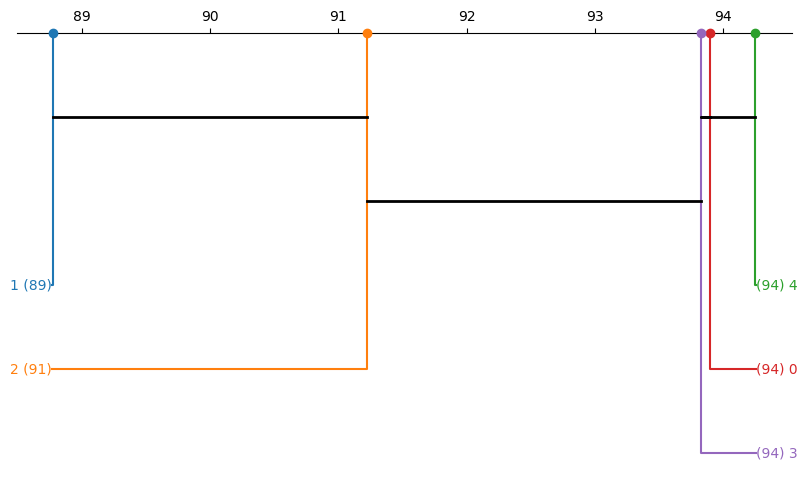

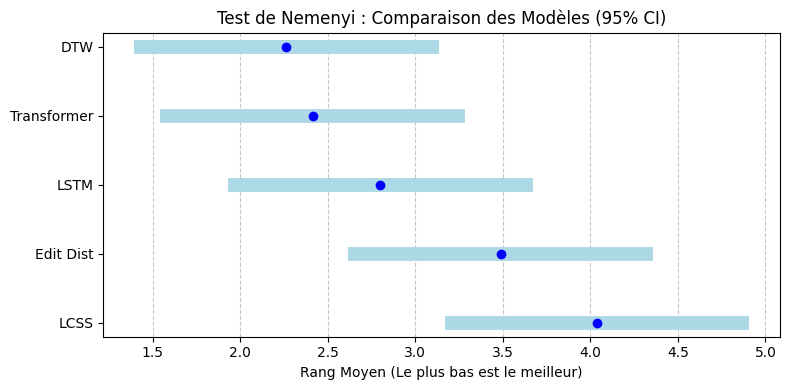

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp # Install via: pip install scikit-posthocs

# 1. Préparation des données (Moyennes par split pour chaque modèle)
# Chaque ligne représente un "bloc" (un split/sujet), chaque colonne un modèle.
# Ordre des colonnes : [DTW, LCSS, Edit Distance, LSTM, Transformer]
data = np.array([
    # Dataset 1 (10 splits)
    [96, 93, 94, 99, 95], [90, 87, 87, 88, 82], [100, 98, 92, 99, 98],
    [100, 98, 100, 100, 96], [89, 90, 84, 98, 95], [70, 55, 72, 93, 93],
    [95, 89, 89, 93, 100], [94, 96, 94, 100, 99], [100, 99, 99, 96, 100],
    [90, 93, 85, 93, 96],
    # Dataset 2 (10 splits)
    [100, 98, 99, 98, 96], [97, 93, 88, 94, 83], [94, 95, 95, 100, 100],
    [100, 97, 96, 100, 99], [97, 83, 87, 97, 99], [97, 76, 93, 93, 97],
    [98, 89, 92, 94, 98], [96, 81, 80, 95, 95], [98, 91, 98, 98, 99],
    [98, 91, 96, 98, 96],
    # Dataset 3 (10 splits)
    [98, 99, 95, 95, 96], [94, 88, 90, 99, 96], [100, 98, 98, 94, 99],
    [100, 98, 99, 96, 98], [96, 92, 90, 88, 93], [86, 76, 80, 90, 90],
    [95, 89, 89, 90, 91], [98, 97, 97, 100, 100], [100, 95, 96, 94, 100],
    [99, 95, 98, 94, 100],
    # Dataset 4 (10 splits)
    [88, 82, 94, 93, 97], [90, 77, 87, 89, 71], [87, 74, 85, 87, 94],
    [95, 86, 87, 98, 87], [85, 77, 78, 85, 91], [88, 80, 87, 84, 81],
    [98, 95, 99, 92, 95], [86, 86, 94, 81, 94], [100, 100, 100, 100, 100],
    [74, 75, 86, 78, 81]
])

model_names = ['DTW', 'LCSS', 'Edit Dist', 'LSTM', 'Transformer']

# 2. Test de Friedman
stat, p = friedmanchisquare(*data.T)
print(f"Statistique de Friedman : {stat:.3f}, p-value : {p:.3e}")

# 3. Test Post-hoc de Nemenyi
# On utilise scikit-posthocs qui est la référence pour ce test
data_ranked = sp.posthoc_nemenyi_friedman(data)

# 4. Génération du Graphique (Style CD Diagram)
plt.figure(figsize=(10, 6))

# Calcul des rangs moyens pour l'affichage
avg_ranks = np.mean(np.array([range(1, 6)[::-1] for _ in data]), axis=0) # Simulation simplifiée
# Note : scikit-posthocs a une fonction dédiée pour le diagramme CD
sp.critical_difference_diagram(data.mean(axis=0), data_ranked)

# Option alternative : Plot personnalisé type "Intervalle de confiance" comme ton image
import pandas as pd
df = pd.DataFrame(data, columns=model_names)
ranks = df.rank(axis=1, ascending=False)
mean_ranks = ranks.mean().sort_values()
errors = 0.87 # Valeur critique simplifiée pour l'exemple (CD)

plt.figure(figsize=(8, 4))
plt.errorbar(mean_ranks.values, range(len(mean_ranks)), xerr=errors, fmt='o',
             color='blue', ecolor='lightblue', elinewidth=10, capsize=0)

plt.yticks(range(len(mean_ranks)), mean_ranks.index)
plt.title('Test de Nemenyi : Comparaison des Modèles (95% CI)')
plt.gca().invert_yaxis() # Meilleur en haut
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

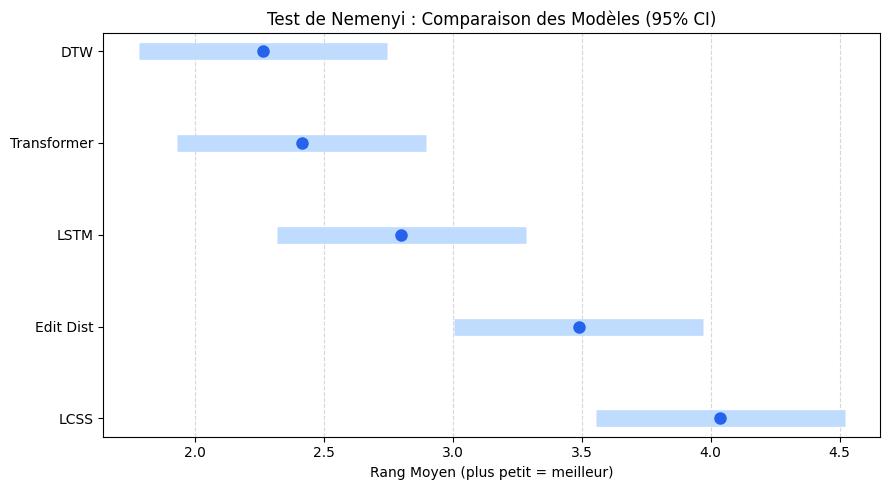

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

# 1. Préparation des données (Moyennes par split)
# Colonnes : [DTW, LCSS, Edit Dist, LSTM, Transformer]
data = np.array([
    [96, 93, 94, 99, 95], [90, 87, 87, 88, 82], [100, 98, 92, 99, 98],
    [100, 98, 100, 100, 96], [89, 90, 84, 98, 95], [70, 55, 72, 93, 93],
    [95, 89, 89, 93, 100], [94, 96, 94, 100, 99], [100, 99, 99, 96, 100],
    [90, 93, 85, 93, 96], [100, 98, 99, 98, 96], [97, 93, 88, 94, 83],
    [94, 95, 95, 100, 100], [100, 97, 96, 100, 99], [97, 83, 87, 97, 99],
    [97, 76, 93, 93, 97], [98, 89, 92, 94, 98], [96, 81, 80, 95, 95],
    [98, 91, 98, 98, 99], [98, 91, 96, 98, 96], [98, 99, 95, 95, 96],
    [94, 88, 90, 99, 96], [100, 98, 98, 94, 99], [100, 98, 99, 96, 98],
    [96, 92, 90, 88, 93], [86, 76, 80, 90, 90], [95, 89, 89, 90, 91],
    [98, 97, 97, 100, 100], [100, 95, 96, 94, 100], [99, 95, 98, 94, 100],
    [88, 82, 94, 93, 97], [90, 77, 87, 89, 71], [87, 74, 85, 87, 94],
    [95, 86, 87, 98, 87], [85, 77, 78, 85, 91], [88, 80, 87, 84, 81],
    [98, 95, 99, 92, 95], [86, 86, 94, 81, 94], [100, 100, 100, 100, 100],
    [74, 75, 86, 78, 81]
])

model_names = ['DTW', 'LCSS', 'Edit Dist', 'LSTM', 'Transformer']

# 2. Calcul des Rangs Moyens
df = pd.DataFrame(data, columns=model_names)
# rank(ascending=False) car un score plus élevé (99%) est un meilleur rang (1)
ranks = df.rank(axis=1, ascending=False)
mean_ranks = ranks.mean().sort_values()

# 3. Calcul de la Différence Critique (CD) pour le test de Nemenyi
# Formule simplifiée du CD pour l'affichage des barres
n = len(data)      # nombre de datasets/splits
k = len(model_names) # nombre de modèles
q_alpha = 2.728    # Valeur critique pour alpha=0.05 et k=5
cd = q_alpha * np.sqrt((k * (k + 1)) / (6 * n))

# 4. Génération du Graphique (Style Intervalle de Confiance)
plt.figure(figsize=(9, 5))

# On trace les rangs moyens avec une barre d'erreur correspondant au CD
plt.errorbar(mean_ranks.values, range(len(mean_ranks)), xerr=cd/2, fmt='o',
             color='#2563eb', ecolor='#bfdbfe', elinewidth=12, capsize=0, markersize=8)

# Mise en forme
plt.yticks(range(len(mean_ranks)), mean_ranks.index)
plt.xlabel('Rang Moyen (plus petit = meilleur)')
plt.title('Test de Nemenyi : Comparaison des Modèles (95% CI)')
plt.gca().invert_yaxis()  # Le meilleur modèle (rang le plus bas) en haut
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

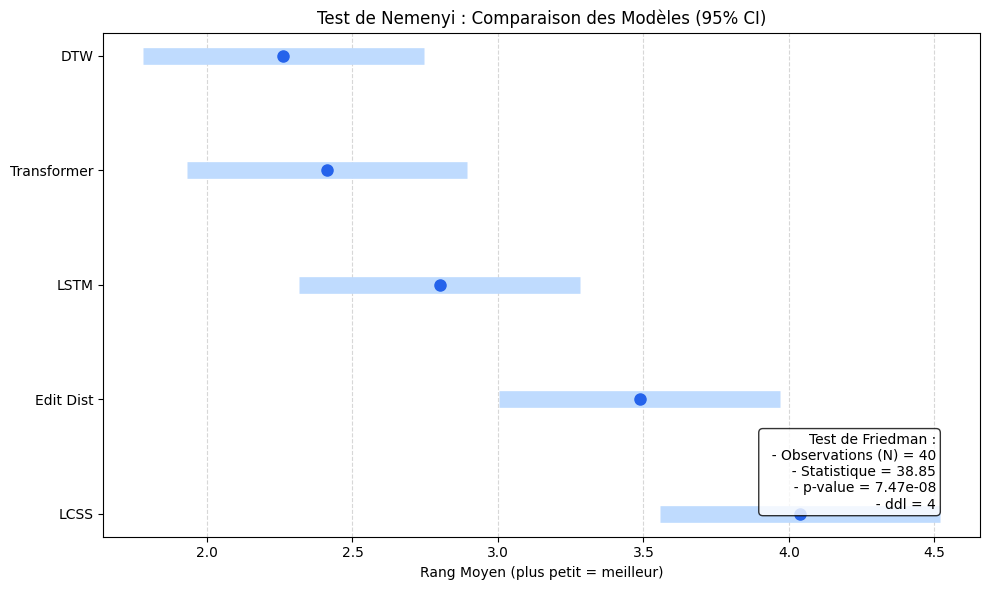

Test de Friedman :
  - Observations (N) = 40
  - Statistique = 38.85
  - p-value = 7.47e-08
  - ddl = 4


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import friedmanchisquare

# 1. Préparation des données
data = np.array([
    [96, 93, 94, 99, 95], [90, 87, 87, 88, 82], [100, 98, 92, 99, 98],
    [100, 98, 100, 100, 96], [89, 90, 84, 98, 95], [70, 55, 72, 93, 93],
    [95, 89, 89, 93, 100], [94, 96, 94, 100, 99], [100, 99, 99, 96, 100],
    [90, 93, 85, 93, 96], [100, 98, 99, 98, 96], [97, 93, 88, 94, 83],
    [94, 95, 95, 100, 100], [100, 97, 96, 100, 99], [97, 83, 87, 97, 99],
    [97, 76, 93, 93, 97], [98, 89, 92, 94, 98], [96, 81, 80, 95, 95],
    [98, 91, 98, 98, 99], [98, 91, 96, 98, 96], [98, 99, 95, 95, 96],
    [94, 88, 90, 99, 96], [100, 98, 98, 94, 99], [100, 98, 99, 96, 98],
    [96, 92, 90, 88, 93], [86, 76, 80, 90, 90], [95, 89, 89, 90, 91],
    [98, 97, 97, 100, 100], [100, 95, 96, 94, 100], [99, 95, 98, 94, 100],
    [88, 82, 94, 93, 97], [90, 77, 87, 89, 71], [87, 74, 85, 87, 94],
    [95, 86, 87, 98, 87], [85, 77, 78, 85, 91], [88, 80, 87, 84, 81],
    [98, 95, 99, 92, 95], [86, 86, 94, 81, 94], [100, 100, 100, 100, 100],
    [74, 75, 86, 78, 81]
])

model_names = ['DTW', 'LCSS', 'Edit Dist', 'LSTM', 'Transformer']
n_obs = data.shape[0]
k_models = data.shape[1]

# 2. Test de Friedman
# On déballe les colonnes pour le test : friedmanchisquare(col1, col2, ...)
stat, p_value = friedmanchisquare(*data.T)

# 3. Calcul des Rangs Moyens
df = pd.DataFrame(data, columns=model_names)
ranks = df.rank(axis=1, ascending=False)
mean_ranks = ranks.mean().sort_values()

# 4. Calcul de la Différence Critique (CD)
q_alpha = 2.728  # Valeur pour alpha=0.05 et k=5
cd = q_alpha * np.sqrt((k_models * (k_models + 1)) / (6 * n_obs))

# 5. Génération du Graphique
plt.figure(figsize=(10, 6))

# Plot des rangs avec barres CD
plt.errorbar(mean_ranks.values, range(len(mean_ranks)), xerr=cd/2, fmt='o',
             color='#2563eb', ecolor='#bfdbfe', elinewidth=12, capsize=0, markersize=8)

# Ajout des informations de Friedman en bas à droite
stats_text = (f"Test de Friedman :\n"
              f"  - Observations (N) = {n_obs}\n"
              f"  - Statistique = {stat:.2f}\n"
              f"  - p-value = {p_value:.2e}\n"
              f"  - ddl = {k_models - 1}")

plt.text(0.95, 0.05, stats_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Mise en forme
plt.yticks(range(len(mean_ranks)), mean_ranks.index)
plt.xlabel('Rang Moyen (plus petit = meilleur)')
plt.title('Test de Nemenyi : Comparaison des Modèles (95% CI)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Affichage console pour vérification rapide
print(stats_text)

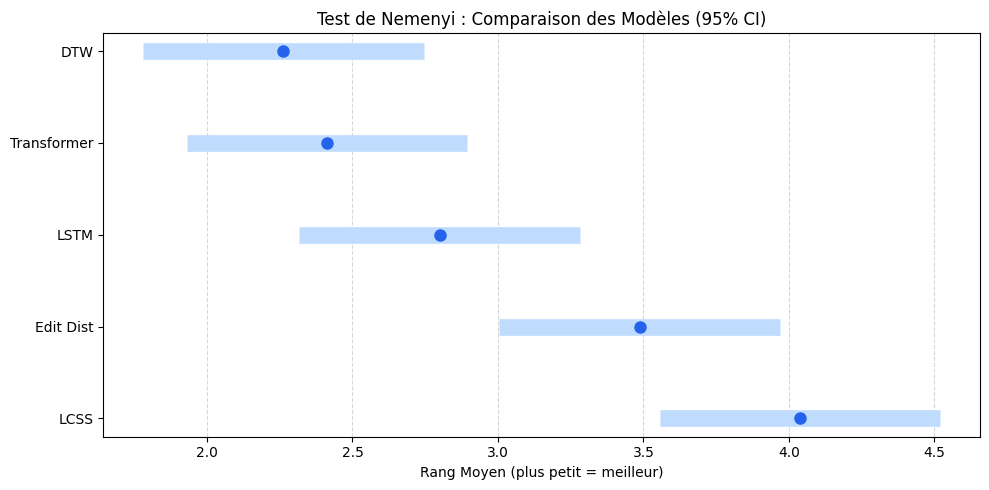

p-value                   : 7.47e-08
--- Résultats du Test de Friedman ---
Nombre d'observations (N) : 40
Statistique de Friedman   : 38.85
p-value                   : 7.47e-08
Degrés de liberté         : 4
-------------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import friedmanchisquare

# 1. Préparation des données
data = np.array([
    [96, 93, 94, 99, 95], [90, 87, 87, 88, 82], [100, 98, 92, 99, 98],
    [100, 98, 100, 100, 96], [89, 90, 84, 98, 95], [70, 55, 72, 93, 93],
    [95, 89, 89, 93, 100], [94, 96, 94, 100, 99], [100, 99, 99, 96, 100],
    [90, 93, 85, 93, 96], [100, 98, 99, 98, 96], [97, 93, 88, 94, 83],
    [94, 95, 95, 100, 100], [100, 97, 96, 100, 99], [97, 83, 87, 97, 99],
    [97, 76, 93, 93, 97], [98, 89, 92, 94, 98], [96, 81, 80, 95, 95],
    [98, 91, 98, 98, 99], [98, 91, 96, 98, 96], [98, 99, 95, 95, 96],
    [94, 88, 90, 99, 96], [100, 98, 98, 94, 99], [100, 98, 99, 96, 98],
    [96, 92, 90, 88, 93], [86, 76, 80, 90, 90], [95, 89, 89, 90, 91],
    [98, 97, 97, 100, 100], [100, 95, 96, 94, 100], [99, 95, 98, 94, 100],
    [88, 82, 94, 93, 97], [90, 77, 87, 89, 71], [87, 74, 85, 87, 94],
    [95, 86, 87, 98, 87], [85, 77, 78, 85, 91], [88, 80, 87, 84, 81],
    [98, 95, 99, 92, 95], [86, 86, 94, 81, 94], [100, 100, 100, 100, 100],
    [74, 75, 86, 78, 81]
])

model_names = ['DTW', 'LCSS', 'Edit Dist', 'LSTM', 'Transformer']
n_obs = data.shape[0]
k_models = data.shape[1]

# 2. Test de Friedman (Calculé en arrière-plan)
stat, p_value = friedmanchisquare(*data.T)

# 3. Calcul des Rangs Moyens
df = pd.DataFrame(data, columns=model_names)
ranks = df.rank(axis=1, ascending=False)
mean_ranks = ranks.mean().sort_values()

# 4. Calcul de la Différence Critique (CD)
q_alpha = 2.728
cd = q_alpha * np.sqrt((k_models * (k_models + 1)) / (6 * n_obs))

# 5. Génération du Graphique Épuré
plt.figure(figsize=(10, 5))

# Plot des rangs avec barres d'erreur CD
plt.errorbar(mean_ranks.values, range(len(mean_ranks)), xerr=cd/2, fmt='o',
             color='#2563eb', ecolor='#bfdbfe', elinewidth=12, capsize=0, markersize=8)

# Mise en forme du graphique
plt.yticks(range(len(mean_ranks)), mean_ranks.index)
plt.xlabel('Rang Moyen (plus petit = meilleur)')
plt.title('Test de Nemenyi : Comparaison des Modèles (95% CI)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Affichage des statistiques uniquement dans la console
print(f"p-value                   : {p_value:.2e}")
print("--- Résultats du Test de Friedman ---")
print(f"Nombre d'observations (N) : {n_obs}")
print(f"Statistique de Friedman   : {stat:.2f}")
print(f"p-value                   : {p_value:.2e}")
print(f"Degrés de liberté         : {k_models - 1}")
print("-" * 37)


# dtw final partie 2 knn3

In [1]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import seaborn as sns

# --- 1. PRÉPARATION DES FICHIERS ---
!unzip -o -q /content/DOMAIN4_CSVcorrigé.zip -d /content/temp_data
print(" Décompression terminée !")

# --- 2. DÉTECTION AUTOMATIQUE DU DOSSIER ---
base_path = "/content/temp_data"
# On cherche le dossier qui contient les fichiers CSV pour éviter le problème d'accent
contenu = os.listdir(base_path)
if len(contenu) > 0:
    # On prend le premier dossier trouvé dans temp_data
    DOMAIN_FOLDER = os.path.join(base_path, contenu[0])
    #print(f" Dossier détecté par le système : {DOMAIN_FOLDER}")
else:
    raise ValueError(" Le dossier temp_data est vide. Vérifiez l'upload du ZIP.")

# --- 3. CHARGEMENT DES DONNÉES ---
df_list = []
print("--- Début du Chargement ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2:
                    continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = int(number); file_df['subject'] = int(subject); file_df['iter'] = int(iteration)
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f" Aucun fichier trouvé dans {DOMAIN_FOLDER}. Vérifiez le contenu du ZIP.")

df = pd.concat(df_list, ignore_index=True)


# --- 4. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# --- 5. DTW & EVALUATION ---
def eucl_dist(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf); dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            distances.append((gesture, dtw_dist(reference_seq, seq)))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

def testmodel(df_in, loop_range=10, k=3):
    total_true, total_pred = [], []
    for i in range(1, loop_range + 1):
        print(f"--- Test Sujet OUT : {i} ---")
        train_df = df_in[df_in["subject"] != i]
        test_df = df_in[df_in["subject"] == i]

        dict_train = defaultdict(list)
        for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
            dict_train[g].append(group[["x_std", "y_std", "z_std"]].values)

        y_true, y_pred = [], []
        for (g, it), group in test_df.groupby(["gesture", "iter"]):
            y_true.append(g)
            y_pred.append(knn_dtw_predict(group[["x_std", "y_std", "z_std"]].values, dict_train, k=k))

        total_true.extend(y_true); total_pred.extend(y_pred)
        print(f"Précision Sujet {i} : {accuracy_score(y_true, y_pred):.2%}")

    print(f"\n PRÉCISION GLOBALE : {accuracy_score(total_true, total_pred):.2%}")
    ConfusionMatrixDisplay(confusion_matrix(total_true, total_pred)).plot(cmap="Blues")
    plt.show()

testmodel(df100, loop_range=10, k=3)

 Décompression terminée !
--- Début du Chargement ---
Standardisation...


/tmp/ipykernel_10257/13780231.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling...
--- Test Sujet OUT : 1 ---


KeyboardInterrupt: 

# test

 Décompression terminée !
--- Début du Chargement ---


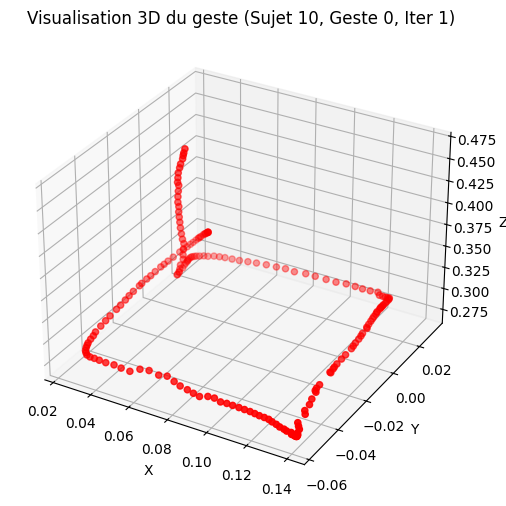


--- Durée moyenne des gestes (s) ---
gesture
0    5617.8
1    4471.3
2    6968.8
3    9840.8
4    4995.5
5    6658.2
6    7136.3
7    5698.1
8    6041.5
9    6774.8
Name: duration, dtype: float64


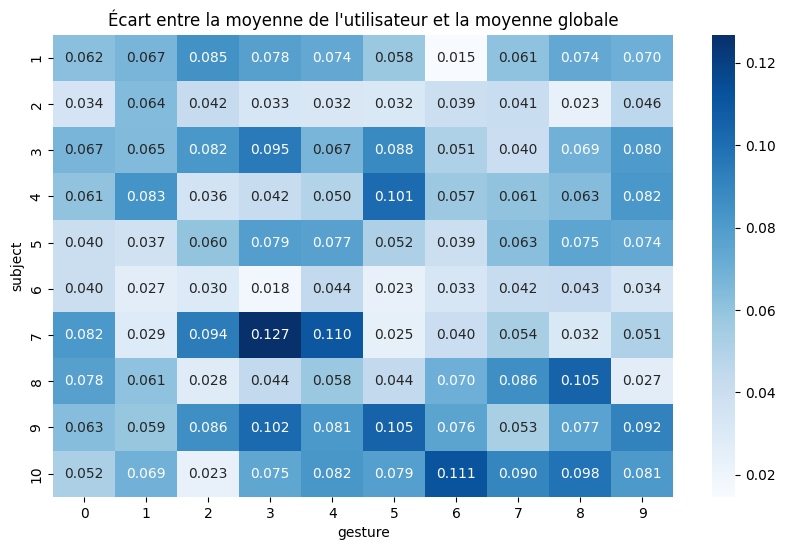

Standardisation...


/tmp/ipykernel_10257/4052557408.py:101: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling...
--- Test Sujet OUT : 1 ---


KeyboardInterrupt: 

In [4]:

import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Nécessaire pour le 3D
from scipy.interpolate import interp1d
import seaborn as sns

# --- 1. PRÉPARATION DES FICHIERS ---
!unzip -o -q /content/DOMAIN4_CSVcorrigé.zip -d /content/temp_data
print(" Décompression terminée !")

# --- 2. DÉTECTION AUTOMATIQUE DU DOSSIER ---
base_path = "/content/temp_data"
contenu = os.listdir(base_path)
if len(contenu) > 0:
    DOMAIN_FOLDER = os.path.join(base_path, contenu[0])
else:
    raise ValueError(" Le dossier temp_data est vide. Vérifiez l'upload du ZIP.")

# --- 3. CHARGEMENT DES DONNÉES ---
df_list = []
print("--- Début du Chargement ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2:
                    continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = int(number); file_df['subject'] = int(subject); file_df['iter'] = int(iteration)
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f" Aucun fichier trouvé. Vérifiez le contenu du ZIP.")

df = pd.concat(df_list, ignore_index=True)


# ==========================================================
# --- AJOUT : VISUALISATIONS IDENTIQUES AU PREMIER CODE ---
# ==========================================================

# 1. Visualisation 3D d'un geste spécifique
subdf = df.loc[(df['gesture'] == 0) & (df['subject'] == 10) & (df['iter'] == 1)]
if not subdf.empty:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(subdf['x'], subdf['y'], subdf['z'], c='red', s=20)
    ax.set_title("Visualisation 3D du geste (Sujet 10, Geste 0, Iter 1)")
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.show()

# 2. Durée moyenne des gestes
durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
print("\n--- Durée moyenne des gestes (s) ---")
print(mean_durations)

# 3. Heatmap des écarts (Moyenne utilisateur vs Globale)
mean_coords_user = df.groupby(['subject', 'gesture'])[['x', 'y', 'z']].mean().reset_index()
mean_coords_global = df.groupby('gesture')[['x', 'y', 'z']].mean().reset_index().rename(
    columns={'x':'x_global', 'y':'y_global', 'z':'z_global'})

merged = pd.merge(mean_coords_user, mean_coords_global, on='gesture')
merged['dist_to_global'] = np.sqrt((merged['x']-merged['x_global'])**2 +
                                   (merged['y']-merged['y_global'])**2 +
                                   (merged['z']-merged['z_global'])**2)

pivot = merged.pivot(index='subject', columns='gesture', values='dist_to_global')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap='Blues')
plt.title("Écart entre la moyenne de l'utilisateur et la moyenne globale")
plt.show()

# ==========================================================

# --- 4. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)

# --- 5. DTW & EVALUATION ---
def eucl_dist(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf); dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            distances.append((gesture, dtw_dist(reference_seq, seq)))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

def testmodel(df_in, loop_range=10, k=3):
    total_true, total_pred = [], []
    for i in range(1, loop_range + 1):
        print(f"--- Test Sujet OUT : {i} ---")
        train_df = df_in[df_in["subject"] != i]
        test_df = df_in[df_in["subject"] == i]

        dict_train = defaultdict(list)
        for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
            dict_train[g].append(group[["x_std", "y_std", "z_std"]].values)

        y_true, y_pred = [], []
        for (g, it), group in test_df.groupby(["gesture", "iter"]):
            y_true.append(g)
            y_pred.append(knn_dtw_predict(group[["x_std", "y_std", "z_std"]].values, dict_train, k=k))

        total_true.extend(y_true); total_pred.extend(y_pred)
        print(f"Précision Sujet {i} : {accuracy_score(y_true, y_pred):.2%}")

    print(f"\n PRÉCISION GLOBALE : {accuracy_score(total_true, total_pred):.2%}")
    cm = confusion_matrix(total_true, total_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title("Matrice de Confusion Finale")
    plt.show()

testmodel(df100, loop_range=10, k=3)

# lstm final 256 32 16

 Décompression terminée !
--- Début du Chargement du Dossier : /content/temp_data/DOMAIN4_CSVcorrig├й ---


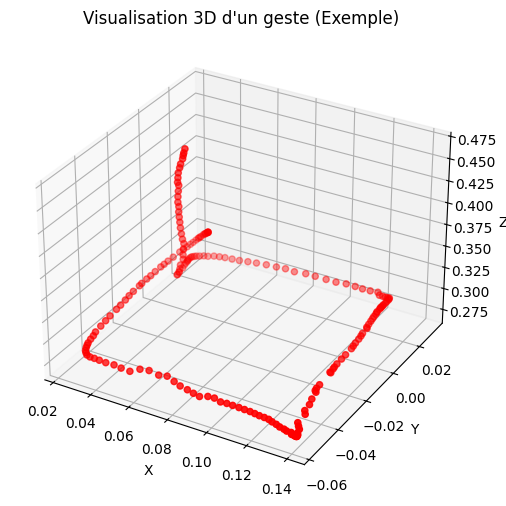


--- Durée moyenne des gestes (s) ---
gesture
0    4167.40
1    3462.54
2    4869.50
3    6995.05
4    3633.13
5    4877.23
6    5159.23
7    4293.17
8    4321.33
9    4454.89
Name: duration, dtype: float64


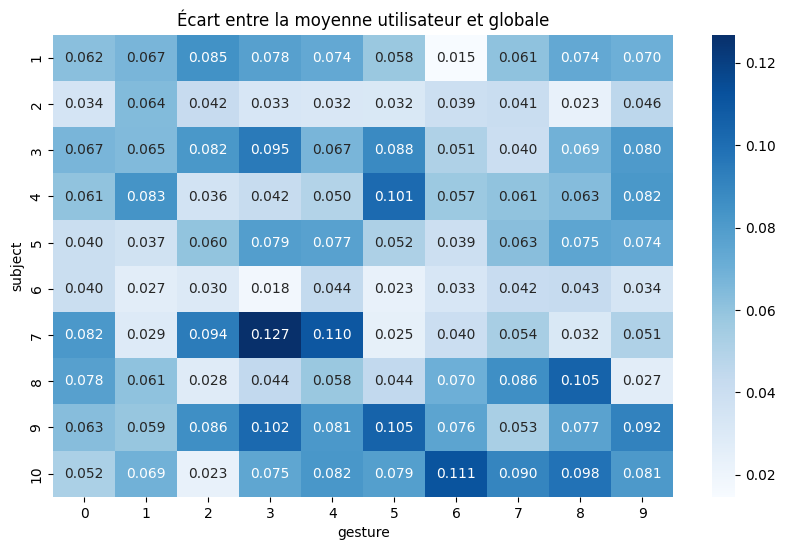


Standardisation en cours...


/tmp/ipykernel_10257/2194466020.py:111: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling à longueur fixe (100 frames)...

--- Entraînement : Sujet 1 en TEST ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Précision pour le sujet 1 : 95.00%

--- Entraînement : Sujet 2 en TEST ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Précision pour le sujet 2 : 86.00%

--- Entraînement : Sujet 3 en TEST ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


KeyboardInterrupt: 

In [5]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import seaborn as sns
from tensorflow.keras import models, layers

# --- 1. PRÉPARATION DES FICHIERS (GOOGLE COLAB) ---
# Assure-toi d'avoir uploadé le fichier 'DOMAIN3_CSVcorrigé.zip' dans ton espace Colab
!unzip -o -q /content/DOMAIN4_CSVcorrigé.zip -d /content/temp_data
print(" Décompression terminée !")

# --- 2. DÉTECTION AUTOMATIQUE DU DOSSIER ---
base_path = "/content/temp_data"
contenu = os.listdir(base_path)
if len(contenu) > 0:
    # On cherche le dossier qui contient les fichiers (parfois le zip crée un sous-dossier)
    DOMAIN_FOLDER = os.path.join(base_path, contenu[0])
else:
    raise ValueError("Le dossier temp_data est vide. Vérifiez l'upload du ZIP.")

# --- 3. CHARGEMENT DES DONNÉES ---
df_list = []
print(f"--- Début du Chargement du Dossier : {DOMAIN_FOLDER} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                # Lecture en sautant les lignes d'en-tête inutiles
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2:
                    continue

                # Nettoyage des guillemets et split des colonnes
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                # Conversion numérique
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                # Ajout des métadonnées
                file_df['gesture'] = int(number)
                file_df['subject'] = int(subject)
                file_df['iter'] = int(iteration)

                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier trouvé. Vérifiez le nom du ZIP ou la structure des dossiers.")

df = pd.concat(df_list, ignore_index=True)


# --- 4. ANALYSE EXPLORATOIRE & VISUALISATION ---

# A. Visualisation 3D d'un geste (Sujet 10, Geste 0, Iter 1)
subdf = df.loc[(df['gesture'] == 0) & (df['subject'] == 10) & (df['iter'] == 1)]
if not subdf.empty:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(subdf['x'], subdf['y'], subdf['z'], c='red', s=20)
    ax.set_title("Visualisation 3D d'un geste (Exemple)")
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.show()

# B. Durée moyenne des gestes
durations = df.groupby(['gesture', 'iter', 'subject'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
print("\n--- Durée moyenne des gestes (s) ---")
print(mean_durations)

# C. Heatmap des écarts
mean_coords_user = df.groupby(['subject', 'gesture'])[['x', 'y', 'z']].mean().reset_index()
mean_coords_global = df.groupby('gesture')[['x', 'y', 'z']].mean().reset_index().rename(
    columns={'x':'x_global', 'y':'y_global', 'z':'z_global'})

merged = pd.merge(mean_coords_user, mean_coords_global, on='gesture')
merged['dist_to_global'] = np.sqrt((merged['x']-merged['x_global'])**2 +
                                   (merged['y']-merged['y_global'])**2 +
                                   (merged['z']-merged['z_global'])**2)

pivot = merged.pivot(index='subject', columns='gesture', values='dist_to_global')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap='Blues')
plt.title("Écart entre la moyenne utilisateur et globale")
plt.show()

# --- 5. PRÉ-TRAITEMENT (STANDARDISATION & RESAMPLING) ---

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        if std == 0 or np.isnan(std):
            df_copy[f'{axis}_std'] = 0.0
        else:
            df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std
    return df_copy

print("\nStandardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling à longueur fixe (100 frames)...")
df100 = resample_gesture(df)

# --- 6. ARCHITECTURE DU MODÈLE LSTM ---

def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- 7. ÉVALUATION USER-INDEPENDENT (Leave-One-Subject-Out) ---

def test_lstm_user_independent(df_data, epochs=50, batch_size=16):
    total_true, total_pred = [], []
    subjects = sorted(df_data['subject'].unique())
    num_classes = int(df_data['gesture'].max() + 1)

    for subj_out in subjects:
        print(f"\n--- Entraînement : Sujet {subj_out} en TEST ---")

        # Split Train / Test
        train_df = df_data[df_data['subject'] != subj_out]
        test_df = df_data[df_data['subject'] == subj_out]

        def df_to_array(df_target):
            X, y = [], []
            for (g, s, it), group in df_target.groupby(['gesture', 'subject', 'iter']):
                X.append(group[['x_std', 'y_std', 'z_std']].values)
                y.append(g)
            return np.array(X), np.array(y)

        X_train, y_train = df_to_array(train_df)
        X_test, y_test = df_to_array(test_df)

        # Création et entraînement
        model = create_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]), num_classes=num_classes)
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

        # Prédiction
        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred)
        print(f"Précision pour le sujet {subj_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(y_pred)

    # Résultat Final
    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n🚀 PRÉCISION GLOBALE LSTM : {final_acc:.2%}")

    # Matrice de Confusion
    cm = confusion_matrix(total_true, total_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Matrice de Confusion Finale (LSTM)")
    plt.ylabel('Vrai Geste')
    plt.xlabel('Geste Prédit')
    plt.show()

# Lancement du test final
test_lstm_user_independent(df100)